In [ ]:
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Define the directory path
directory_path = './dsb/code/tools/data1gb'

In [ ]:
# DDL- string parser

# def parse_ddl_for_headers(ddl_string):

#     headers = {}

#     tables = re.findall(
#         r'create table (\w+)\s*\((.*?)\);',
#         ddl_string,
#         re.DOTALL
#     )

#     for table, cols in tables:

#         column_names = re.findall(r'^\s*(\w+)', cols, re.MULTILINE)
#         column_names = [c for c in column_names if c.lower() != "primary"]

#         headers[table] = column_names

#     return headers
# schema_headers = parse_ddl_for_headers(sql_ddl)
# print(parse_ddl_for_headers(sql_ddl))

In [ ]:
schema_headers = {'dbgen_version': ['dv_version', 'dv_create_date', 'dv_create_time', 'dv_cmdline_args'], 'customer_address': ['ca_address_sk', 'ca_address_id', 'ca_street_number', 'ca_street_name', 'ca_street_type', 'ca_suite_number', 'ca_city', 'ca_county', 'ca_state', 'ca_zip', 'ca_country', 'ca_gmt_offset', 'ca_location_type'], 'customer_demographics': ['cd_demo_sk', 'cd_gender', 'cd_marital_status', 'cd_education_status', 'cd_purchase_estimate', 'cd_credit_rating', 'cd_dep_count', 'cd_dep_employed_count', 'cd_dep_college_count'], 'date_dim': ['d_date_sk', 'd_date_id', 'd_date', 'd_month_seq', 'd_week_seq', 'd_quarter_seq', 'd_year', 'd_dow', 'd_moy', 'd_dom', 'd_qoy', 'd_fy_year', 'd_fy_quarter_seq', 'd_fy_week_seq', 'd_day_name', 'd_quarter_name', 'd_holiday', 'd_weekend', 'd_following_holiday', 'd_first_dom', 'd_last_dom', 'd_same_day_ly', 'd_same_day_lq', 'd_current_day', 'd_current_week', 'd_current_month', 'd_current_quarter', 'd_current_year'], 'warehouse': ['w_warehouse_sk', 'w_warehouse_id', 'w_warehouse_name', 'w_warehouse_sq_ft', 'w_street_number', 'w_street_name', 'w_street_type', 'w_suite_number', 'w_city', 'w_county', 'w_state', 'w_zip', 'w_country', 'w_gmt_offset'], 'ship_mode': ['sm_ship_mode_sk', 'sm_ship_mode_id', 'sm_type', 'sm_code', 'sm_carrier', 'sm_contract'], 'time_dim': ['t_time_sk', 't_time_id', 't_time', 't_hour', 't_minute', 't_second', 't_am_pm', 't_shift', 't_sub_shift', 't_meal_time'], 'reason': ['r_reason_sk', 'r_reason_id', 'r_reason_desc'], 'income_band': ['ib_income_band_sk', 'ib_lower_bound', 'ib_upper_bound'], 'item': ['i_item_sk', 'i_item_id', 'i_rec_start_date', 'i_rec_end_date', 'i_item_desc', 'i_current_price', 'i_wholesale_cost', 'i_brand_id', 'i_brand', 'i_class_id', 'i_class', 'i_category_id', 'i_category', 'i_manufact_id', 'i_manufact', 'i_size', 'i_formulation', 'i_color', 'i_units', 'i_container', 'i_manager_id', 'i_product_name'], 'store': ['s_store_sk', 's_store_id', 's_rec_start_date', 's_rec_end_date', 's_closed_date_sk', 's_store_name', 's_number_employees', 's_floor_space', 's_hours', 's_manager', 's_market_id', 's_geography_class', 's_market_desc', 's_market_manager', 's_division_id', 's_division_name', 's_company_id', 's_company_name', 's_street_number', 's_street_name', 's_street_type', 's_suite_number', 's_city', 's_county', 's_state', 's_zip', 's_country', 's_gmt_offset', 's_tax_precentage'], 'call_center': ['cc_call_center_sk', 'cc_call_center_id', 'cc_rec_start_date', 'cc_rec_end_date', 'cc_closed_date_sk', 'cc_open_date_sk', 'cc_name', 'cc_class', 'cc_employees', 'cc_sq_ft', 'cc_hours', 'cc_manager', 'cc_mkt_id', 'cc_mkt_class', 'cc_mkt_desc', 'cc_market_manager', 'cc_division', 'cc_division_name', 'cc_company', 'cc_company_name', 'cc_street_number', 'cc_street_name', 'cc_street_type', 'cc_suite_number', 'cc_city', 'cc_county', 'cc_state', 'cc_zip', 'cc_country', 'cc_gmt_offset', 'cc_tax_percentage'], 'customer': ['c_customer_sk', 'c_customer_id', 'c_current_cdemo_sk', 'c_current_hdemo_sk', 'c_current_addr_sk', 'c_first_shipto_date_sk', 'c_first_sales_date_sk', 'c_salutation', 'c_first_name', 'c_last_name', 'c_preferred_cust_flag', 'c_birth_day', 'c_birth_month', 'c_birth_year', 'c_birth_country', 'c_login', 'c_email_address', 'c_last_review_date'], 'web_site': ['web_site_sk', 'web_site_id', 'web_rec_start_date', 'web_rec_end_date', 'web_name', 'web_open_date_sk', 'web_close_date_sk', 'web_class', 'web_manager', 'web_mkt_id', 'web_mkt_class', 'web_mkt_desc', 'web_market_manager', 'web_company_id', 'web_company_name', 'web_street_number', 'web_street_name', 'web_street_type', 'web_suite_number', 'web_city', 'web_county', 'web_state', 'web_zip', 'web_country', 'web_gmt_offset', 'web_tax_percentage'], 'store_returns': ['sr_returned_date_sk', 'sr_return_time_sk', 'sr_item_sk', 'sr_customer_sk', 'sr_cdemo_sk', 'sr_hdemo_sk', 'sr_addr_sk', 'sr_store_sk', 'sr_reason_sk', 'sr_ticket_number', 'sr_return_quantity', 'sr_return_amt', 'sr_return_tax', 'sr_return_amt_inc_tax', 'sr_fee', 'sr_return_ship_cost', 'sr_refunded_cash', 'sr_reversed_charge', 'sr_store_credit', 'sr_net_loss'], 'household_demographics': ['hd_demo_sk', 'hd_income_band_sk', 'hd_buy_potential', 'hd_dep_count', 'hd_vehicle_count'], 'web_page': ['wp_web_page_sk', 'wp_web_page_id', 'wp_rec_start_date', 'wp_rec_end_date', 'wp_creation_date_sk', 'wp_access_date_sk', 'wp_autogen_flag', 'wp_customer_sk', 'wp_url', 'wp_type', 'wp_char_count', 'wp_link_count', 'wp_image_count', 'wp_max_ad_count'], 'promotion': ['p_promo_sk', 'p_promo_id', 'p_start_date_sk', 'p_end_date_sk', 'p_item_sk', 'p_cost', 'p_response_target', 'p_promo_name', 'p_channel_dmail', 'p_channel_email', 'p_channel_catalog', 'p_channel_tv', 'p_channel_radio', 'p_channel_press', 'p_channel_event', 'p_channel_demo', 'p_channel_details', 'p_purpose', 'p_discount_active'], 'catalog_page': ['cp_catalog_page_sk', 'cp_catalog_page_id', 'cp_start_date_sk', 'cp_end_date_sk', 'cp_department', 'cp_catalog_number', 'cp_catalog_page_number', 'cp_description', 'cp_type'], 'inventory': ['inv_date_sk', 'inv_item_sk', 'inv_warehouse_sk', 'inv_quantity_on_hand'], 'catalog_returns': ['cr_returned_date_sk', 'cr_returned_time_sk', 'cr_item_sk', 'cr_refunded_customer_sk', 'cr_refunded_cdemo_sk', 'cr_refunded_hdemo_sk', 'cr_refunded_addr_sk', 'cr_returning_customer_sk', 'cr_returning_cdemo_sk', 'cr_returning_hdemo_sk', 'cr_returning_addr_sk', 'cr_call_center_sk', 'cr_catalog_page_sk', 'cr_ship_mode_sk', 'cr_warehouse_sk', 'cr_reason_sk', 'cr_order_number', 'cr_return_quantity', 'cr_return_amount', 'cr_return_tax', 'cr_return_amt_inc_tax', 'cr_fee', 'cr_return_ship_cost', 'cr_refunded_cash', 'cr_reversed_charge', 'cr_store_credit', 'cr_net_loss'], 'web_returns': ['wr_returned_date_sk', 'wr_returned_time_sk', 'wr_item_sk', 'wr_refunded_customer_sk', 'wr_refunded_cdemo_sk', 'wr_refunded_hdemo_sk', 'wr_refunded_addr_sk', 'wr_returning_customer_sk', 'wr_returning_cdemo_sk', 'wr_returning_hdemo_sk', 'wr_returning_addr_sk', 'wr_web_page_sk', 'wr_reason_sk', 'wr_order_number', 'wr_return_quantity', 'wr_return_amt', 'wr_return_tax', 'wr_return_amt_inc_tax', 'wr_fee', 'wr_return_ship_cost', 'wr_refunded_cash', 'wr_reversed_charge', 'wr_account_credit', 'wr_net_loss'], 'web_sales': ['ws_sold_date_sk', 'ws_sold_time_sk', 'ws_ship_date_sk', 'ws_item_sk', 'ws_bill_customer_sk', 'ws_bill_cdemo_sk', 'ws_bill_hdemo_sk', 'ws_bill_addr_sk', 'ws_ship_customer_sk', 'ws_ship_cdemo_sk', 'ws_ship_hdemo_sk', 'ws_ship_addr_sk', 'ws_web_page_sk', 'ws_web_site_sk', 'ws_ship_mode_sk', 'ws_warehouse_sk', 'ws_promo_sk', 'ws_order_number', 'ws_quantity', 'ws_wholesale_cost', 'ws_list_price', 'ws_sales_price', 'ws_ext_discount_amt', 'ws_ext_sales_price', 'ws_ext_wholesale_cost', 'ws_ext_list_price', 'ws_ext_tax', 'ws_coupon_amt', 'ws_ext_ship_cost', 'ws_net_paid', 'ws_net_paid_inc_tax', 'ws_net_paid_inc_ship', 'ws_net_paid_inc_ship_tax', 'ws_net_profit'], 'catalog_sales': ['cs_sold_date_sk', 'cs_sold_time_sk', 'cs_ship_date_sk', 'cs_bill_customer_sk', 'cs_bill_cdemo_sk', 'cs_bill_hdemo_sk', 'cs_bill_addr_sk', 'cs_ship_customer_sk', 'cs_ship_cdemo_sk', 'cs_ship_hdemo_sk', 'cs_ship_addr_sk', 'cs_call_center_sk', 'cs_catalog_page_sk', 'cs_ship_mode_sk', 'cs_warehouse_sk', 'cs_item_sk', 'cs_promo_sk', 'cs_order_number', 'cs_quantity', 'cs_wholesale_cost', 'cs_list_price', 'cs_sales_price', 'cs_ext_discount_amt', 'cs_ext_sales_price', 'cs_ext_wholesale_cost', 'cs_ext_list_price', 'cs_ext_tax', 'cs_coupon_amt', 'cs_ext_ship_cost', 'cs_net_paid', 'cs_net_paid_inc_tax', 'cs_net_paid_inc_ship', 'cs_net_paid_inc_ship_tax', 'cs_net_profit'], 'store_sales': ['ss_sold_date_sk', 'ss_sold_time_sk', 'ss_item_sk', 'ss_customer_sk', 'ss_cdemo_sk', 'ss_hdemo_sk', 'ss_addr_sk', 'ss_store_sk', 'ss_promo_sk', 'ss_ticket_number', 'ss_quantity', 'ss_wholesale_cost', 'ss_list_price', 'ss_sales_price', 'ss_ext_discount_amt', 'ss_ext_sales_price', 'ss_ext_wholesale_cost', 'ss_ext_list_price', 'ss_ext_tax', 'ss_coupon_amt', 'ss_net_paid', 'ss_net_paid_inc_tax', 'ss_net_profit']}

In [ ]:
def load_dat_file(path):

    df = pd.read_csv(
        path,
        sep="|",
        header=None,
        engine="python"
    )

    # trailing delimiter
    if df.iloc[:, -1].isna().all():
        df = df.iloc[:, :-1]

    return df

In [ ]:
data_dir = "/content/drive/MyDrive/data1gbDBS/data1gb"

loaded_dfs = {}

for file in os.listdir(data_dir):

    if not file.endswith(".dat"):
        continue

    table = file.replace(".dat", "")

    df = load_dat_file(os.path.join(data_dir, file))

    if table in schema_headers:

        headers = schema_headers[table]

        if len(df.columns) > len(headers):
            df = df.iloc[:, :len(headers)]

        if len(df.columns) < len(headers):
            for i in range(len(headers) - len(df.columns)):
                df[df.shape[1]] = None

        df.columns = headers

    print(f"{table} is loaded")

    loaded_dfs[table] = df

print("Loaded tables:", len(loaded_dfs))

call_center is loaded
item is loaded
customer_address is loaded
household_demographics is loaded
customer_demographics is loaded
customer is loaded
catalog_page is loaded
catalog_sales is loaded
catalog_returns is loaded
date_dim is loaded
income_band is loaded
promotion is loaded
ship_mode is loaded
store is loaded
reason is loaded
inventory is loaded
store_returns is loaded
time_dim is loaded
store_sales is loaded
warehouse is loaded
web_page is loaded
web_returns is loaded
dbgen_version is loaded
web_sales is loaded
web_site is loaded
Loaded tables: 25


In [ ]:
# FD binning

import numpy as np

def freedman_diaconis_bins(data):
    data = np.asarray(data)
    data = data[~np.isnan(data)]

    n = len(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    if iqr == 0:
        return int(np.sqrt(n))  # fallback

    h = 2 * iqr / (n ** (1/3))

    bins = int((data.max() - data.min()) / h)

    return bins

In [ ]:
print(f"max: {loaded_dfs['catalog_returns']['cr_returned_time_sk'].max()}")
print(f"min: {loaded_dfs['catalog_returns']['cr_returned_time_sk'].min()}")
print(f'bins: {freedman_diaconis_bins(loaded_dfs['catalog_returns']['cr_returned_time_sk'])}')

max: 86398
min: 2
bins: 74


In [ ]:
print(f"max: {loaded_dfs['catalog_returns']['cr_item_sk'].max()}")
print(f"min: {loaded_dfs['catalog_returns']['cr_item_sk'].min()}")
print(f'bins: {freedman_diaconis_bins(loaded_dfs['catalog_returns']['cr_item_sk'])}')

max: 18000
min: 1
bins: 62


In [ ]:
print(f"max: {loaded_dfs['web_sales']['ws_item_sk'].max()}")
print(f"min: {loaded_dfs['web_sales']['ws_item_sk'].min()}")
print(f'bins: {freedman_diaconis_bins(loaded_dfs['web_sales']['ws_item_sk'])}')

max: 18000
min: 1
bins: 94


In [ ]:
freedman_diaconis_bins(loaded_dfs['web_sales']['ws_item_sk'])

94

In [ ]:
# Define Integer columns

integer_columns = {}

for name, df in loaded_dfs.items():

    cols = []

    for col in df.columns:
        if np.issubdtype(df[col].dtype, np.integer):
            cols.append(col)

    integer_columns[name] = cols

print(integer_columns)

{'call_center': ['cc_call_center_sk', 'cc_open_date_sk', 'cc_employees', 'cc_sq_ft', 'cc_mkt_id', 'cc_division', 'cc_company', 'cc_street_number', 'cc_zip', 'cc_gmt_offset'], 'item': ['i_item_sk'], 'customer_address': ['ca_address_sk'], 'household_demographics': ['hd_demo_sk', 'hd_income_band_sk', 'hd_dep_count', 'hd_vehicle_count'], 'customer_demographics': ['cd_demo_sk', 'cd_purchase_estimate', 'cd_dep_count', 'cd_dep_employed_count', 'cd_dep_college_count'], 'customer': ['c_customer_sk', 'c_current_addr_sk'], 'catalog_page': ['cp_catalog_page_sk'], 'catalog_sales': ['cs_item_sk', 'cs_order_number'], 'catalog_returns': ['cr_returned_date_sk', 'cr_returned_time_sk', 'cr_item_sk', 'cr_order_number'], 'date_dim': ['d_date_sk', 'd_month_seq', 'd_week_seq', 'd_quarter_seq', 'd_year', 'd_dow', 'd_moy', 'd_dom', 'd_qoy', 'd_fy_year', 'd_fy_quarter_seq', 'd_fy_week_seq', 'd_first_dom', 'd_last_dom', 'd_same_day_ly', 'd_same_day_lq'], 'income_band': ['ib_income_band_sk', 'ib_lower_bound', 'ib

In [ ]:
# Bar-charts - prep and sampling

prepared = {}

for table, cols in integer_columns.items():

    df = loaded_dfs[table]

    for col in cols:

        data = df[col].dropna()

        unique_count = data.nunique()

        if unique_count <= 50:

            vc = data.value_counts().reset_index()
            vc.columns = [col, "count"]

            prepared[(table,col)] = ("categorical", vc)

        else:

            sample = data.sample(
                min(len(data),100000),
                random_state=42
            )

            prepared[(table,col)] = ("continuous", sample)

Coefficient of Variation (CV):
  CV = μ / σ

  σ — стандартное отклонение частот внутри бакета

  μ — средняя частота

In [ ]:
def is_numeric_series(series):
    return pd.api.types.is_numeric_dtype(series)

Skipped call_center.cc_call_center_sk (not numeric)
Skipped call_center.cc_open_date_sk (not numeric)
Skipped call_center.cc_employees (not numeric)
Skipped call_center.cc_sq_ft (not numeric)
Skipped call_center.cc_mkt_id (not numeric)
Skipped call_center.cc_division (not numeric)
Skipped call_center.cc_company (not numeric)
Skipped call_center.cc_street_number (not numeric)
Skipped call_center.cc_zip (not numeric)
Skipped call_center.cc_gmt_offset (not numeric)
item.i_item_sk
0    1
1    2
2    3
Name: i_item_sk, dtype: int64


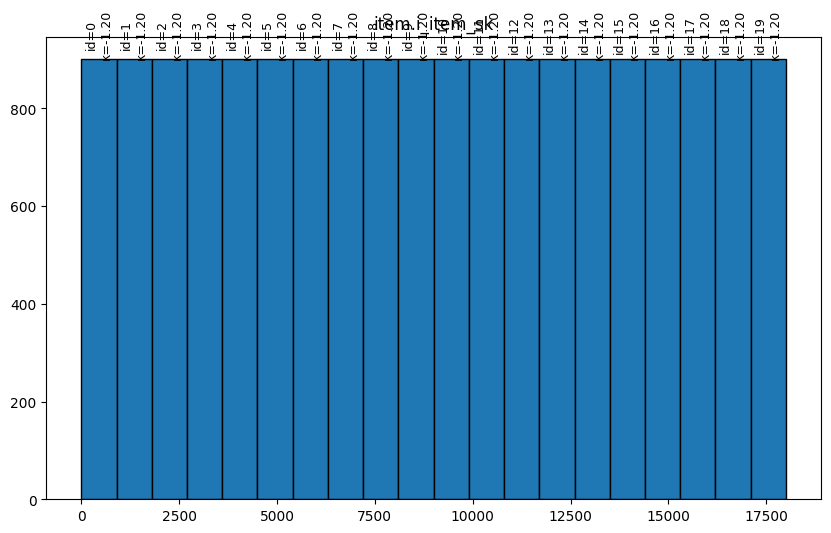

<Figure size 1600x1000 with 0 Axes>

customer_address.ca_address_sk
0    1
1    2
2    3
Name: ca_address_sk, dtype: int64


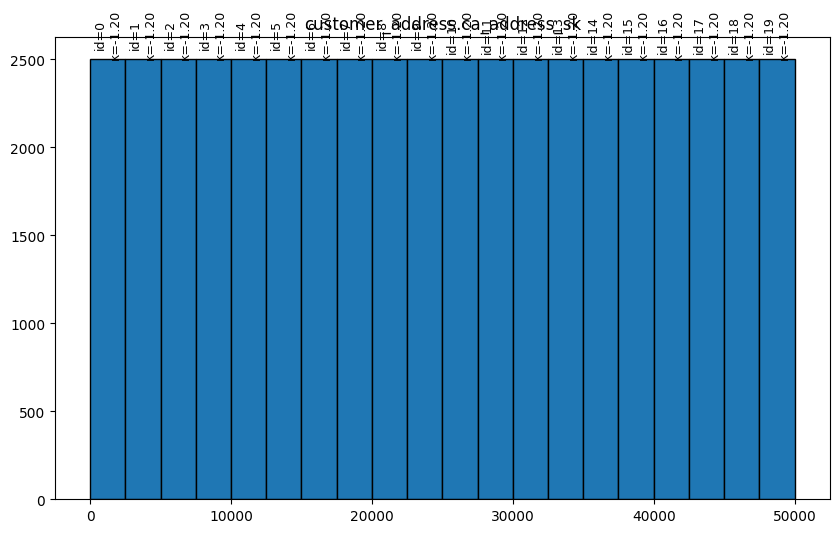

<Figure size 1600x1000 with 0 Axes>

household_demographics.hd_demo_sk
0    1
1    2
2    3
Name: hd_demo_sk, dtype: int64


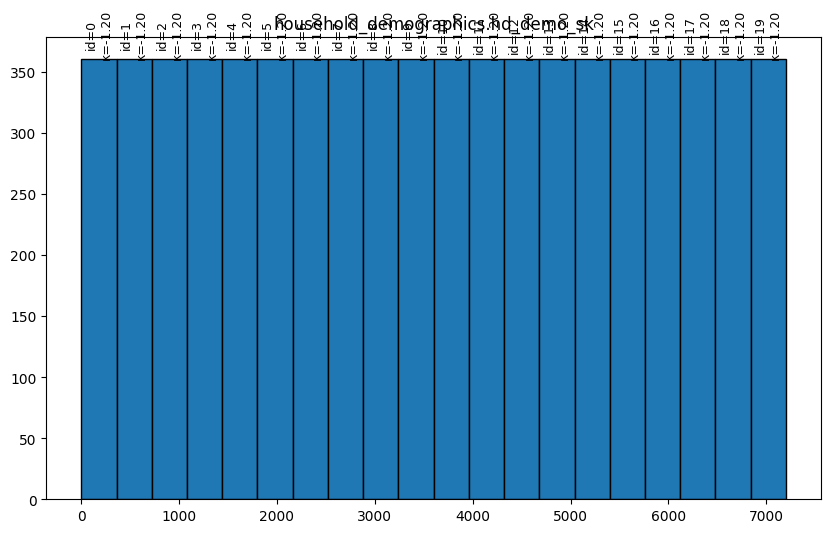

<Figure size 1600x1000 with 0 Axes>

Skipped household_demographics.hd_income_band_sk (not numeric)
Skipped household_demographics.hd_dep_count (not numeric)
Skipped household_demographics.hd_vehicle_count (not numeric)
customer_demographics.cd_demo_sk
0    1
1    2
2    3
Name: cd_demo_sk, dtype: int64


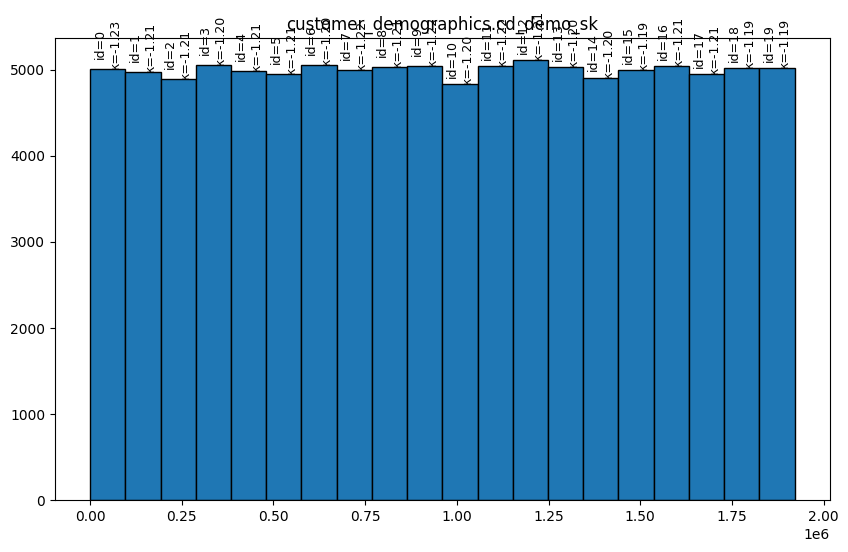

<Figure size 1600x1000 with 0 Axes>

Skipped customer_demographics.cd_purchase_estimate (not numeric)
Skipped customer_demographics.cd_dep_count (not numeric)
Skipped customer_demographics.cd_dep_employed_count (not numeric)
Skipped customer_demographics.cd_dep_college_count (not numeric)
customer.c_customer_sk
0    1
1    2
2    3
Name: c_customer_sk, dtype: int64


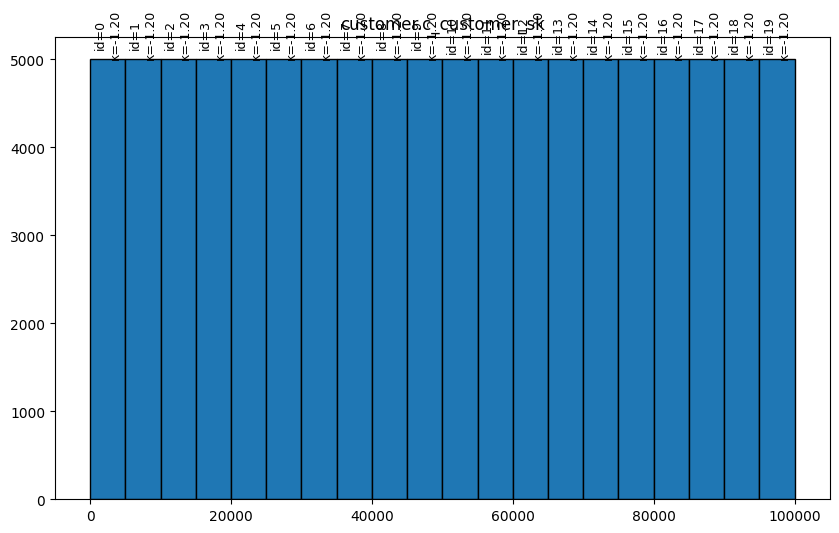

<Figure size 1600x1000 with 0 Axes>

customer.c_current_addr_sk
0    40007
1    14189
2     5496
Name: c_current_addr_sk, dtype: int64


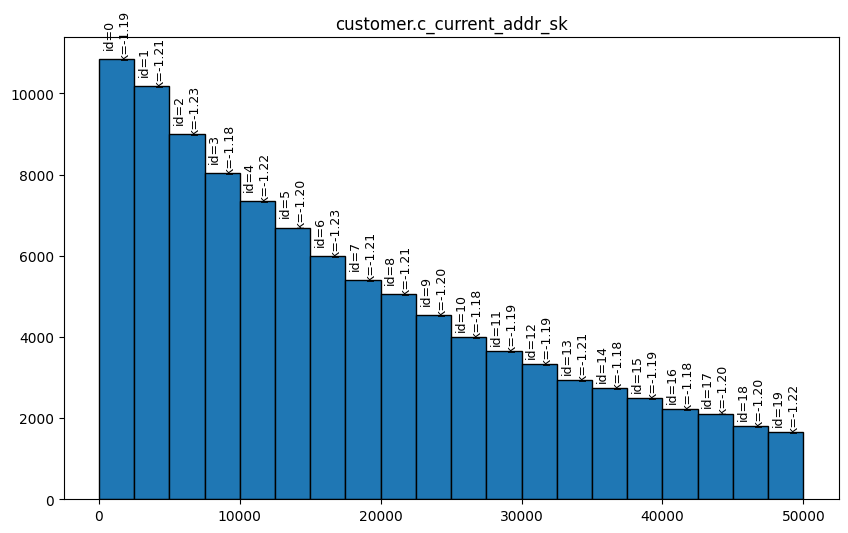

<Figure size 1600x1000 with 0 Axes>

catalog_page.cp_catalog_page_sk
0    1
1    2
2    3
Name: cp_catalog_page_sk, dtype: int64


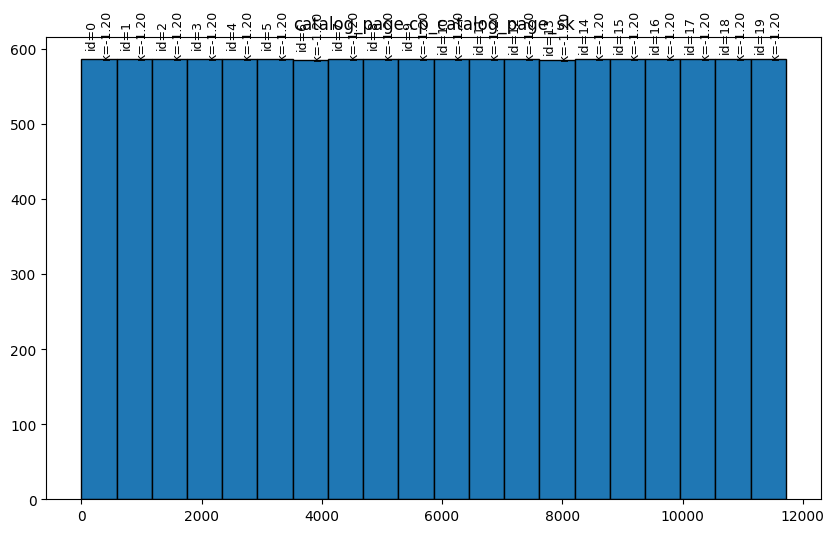

<Figure size 1600x1000 with 0 Axes>

catalog_sales.cs_item_sk
0    17959
1    13480
2     8779
Name: cs_item_sk, dtype: int64


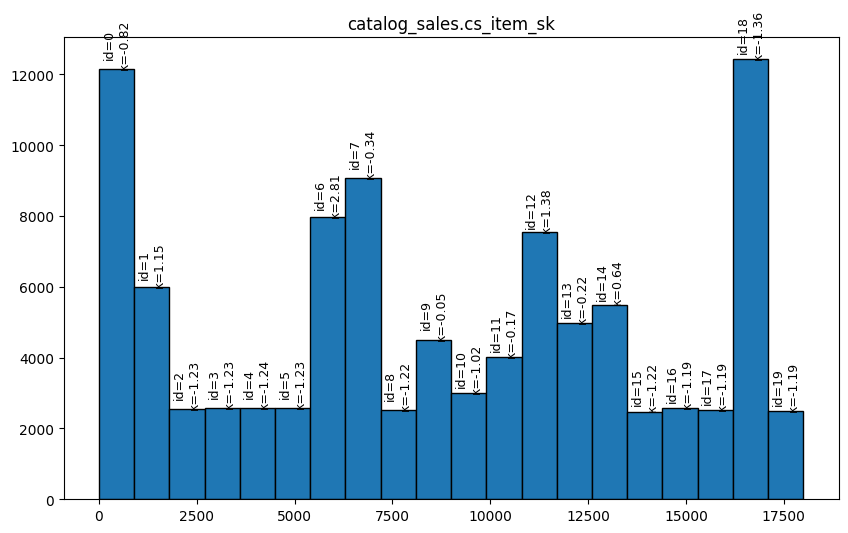

<Figure size 1600x1000 with 0 Axes>

catalog_sales.cs_order_number
0    1
1    1
2    1
Name: cs_order_number, dtype: int64


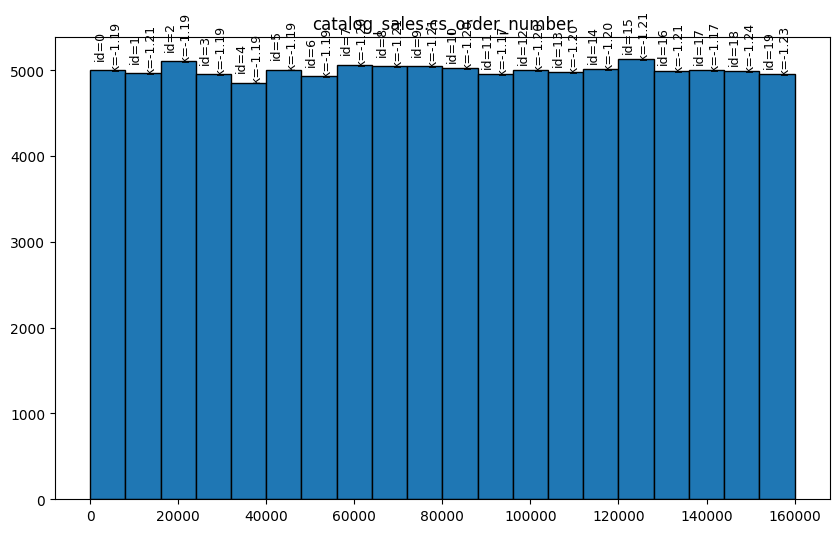

<Figure size 1600x1000 with 0 Axes>

catalog_returns.cr_returned_date_sk
0    2451033
1    2450982
2    2450975
Name: cr_returned_date_sk, dtype: int64


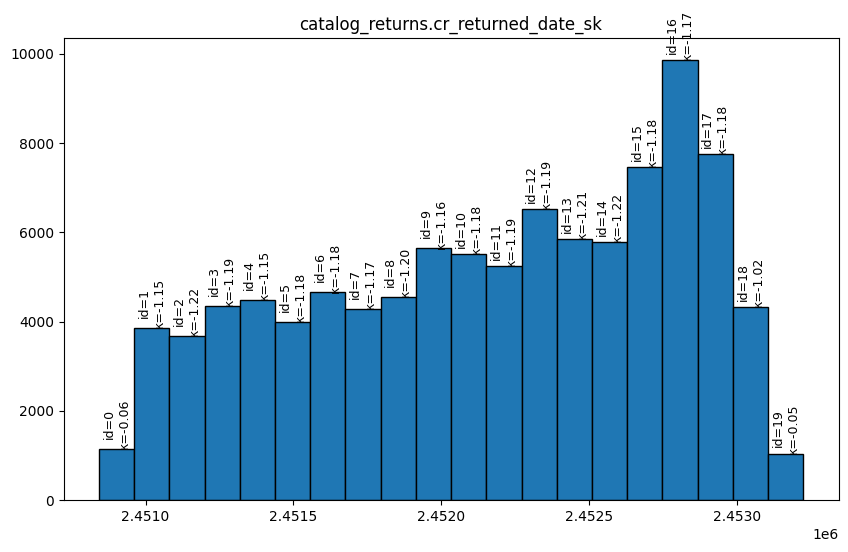

<Figure size 1600x1000 with 0 Axes>

catalog_returns.cr_returned_time_sk
0      224
1    44675
2     7785
Name: cr_returned_time_sk, dtype: int64


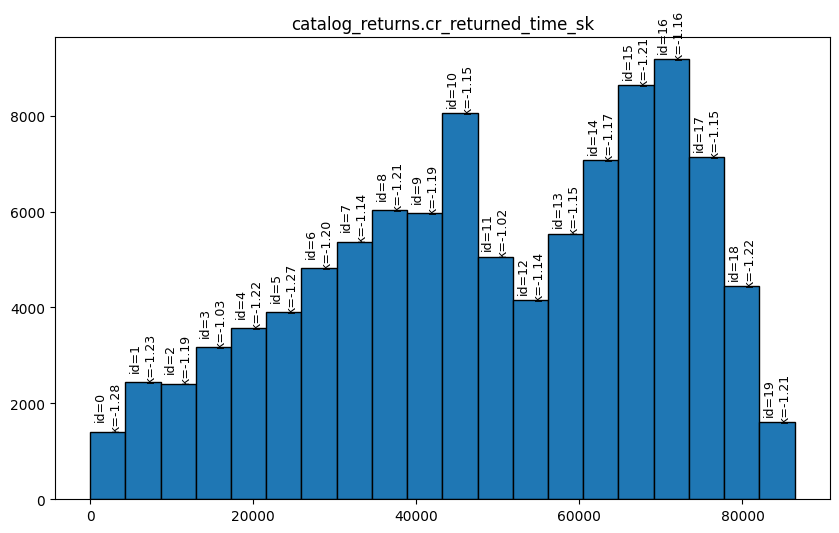

<Figure size 1600x1000 with 0 Axes>

catalog_returns.cr_item_sk
0     4400
1     7105
2    16543
Name: cr_item_sk, dtype: int64


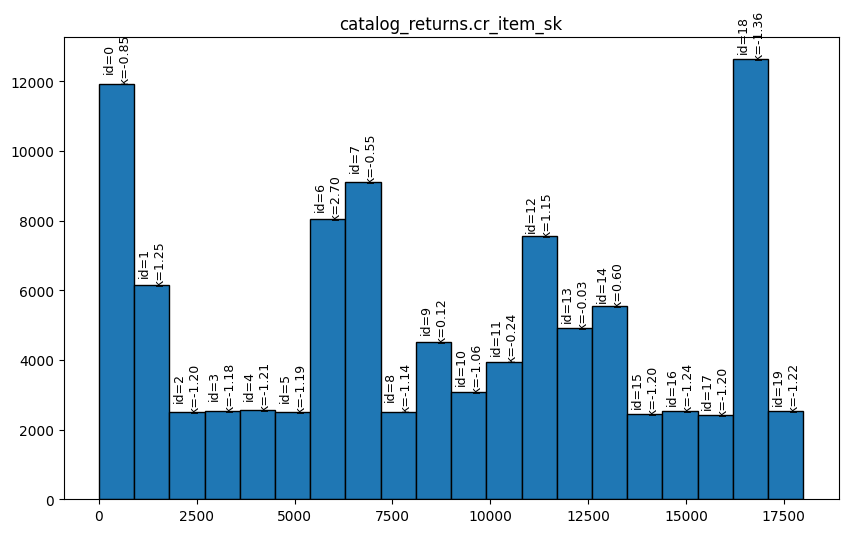

<Figure size 1600x1000 with 0 Axes>

catalog_returns.cr_order_number
0    1
1    3
2    3
Name: cr_order_number, dtype: int64


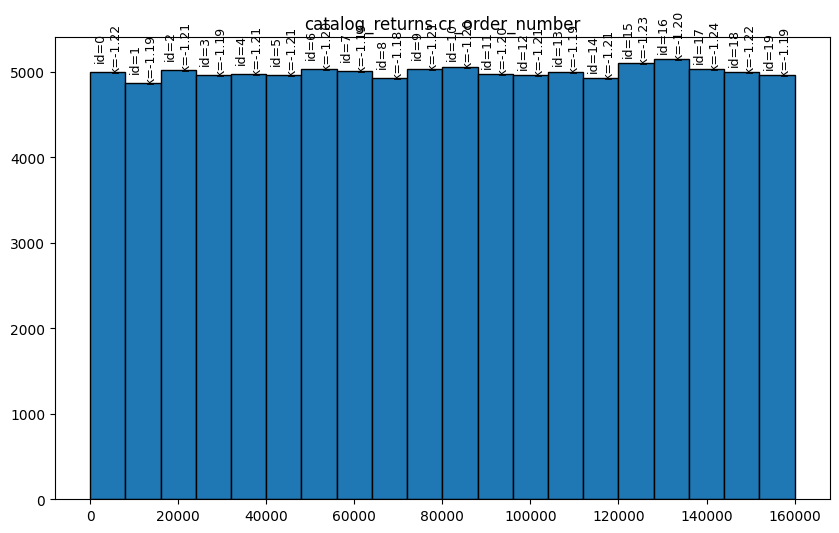

<Figure size 1600x1000 with 0 Axes>

date_dim.d_date_sk
0    2415022
1    2415023
2    2415024
Name: d_date_sk, dtype: int64


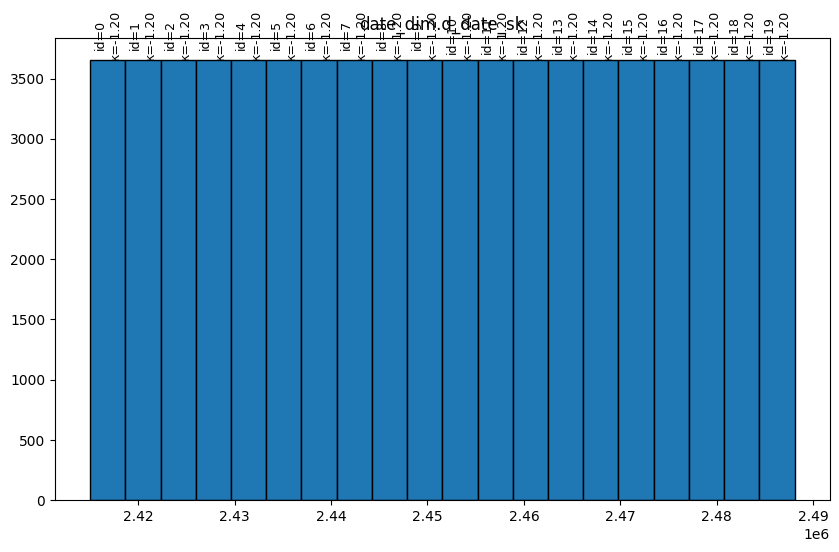

<Figure size 1600x1000 with 0 Axes>

date_dim.d_month_seq
0    0
1    0
2    0
Name: d_month_seq, dtype: int64


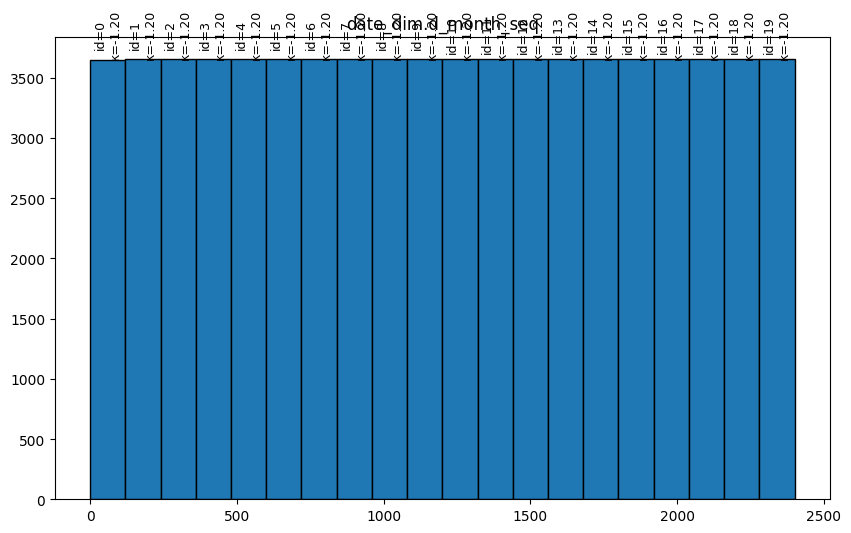

<Figure size 1600x1000 with 0 Axes>

date_dim.d_week_seq
0    1
1    1
2    1
Name: d_week_seq, dtype: int64


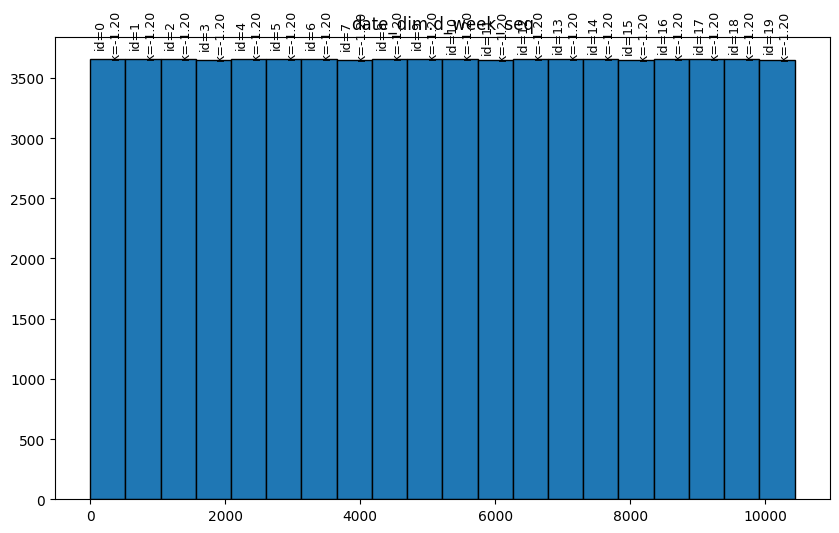

<Figure size 1600x1000 with 0 Axes>

date_dim.d_quarter_seq
0    1
1    1
2    1
Name: d_quarter_seq, dtype: int64


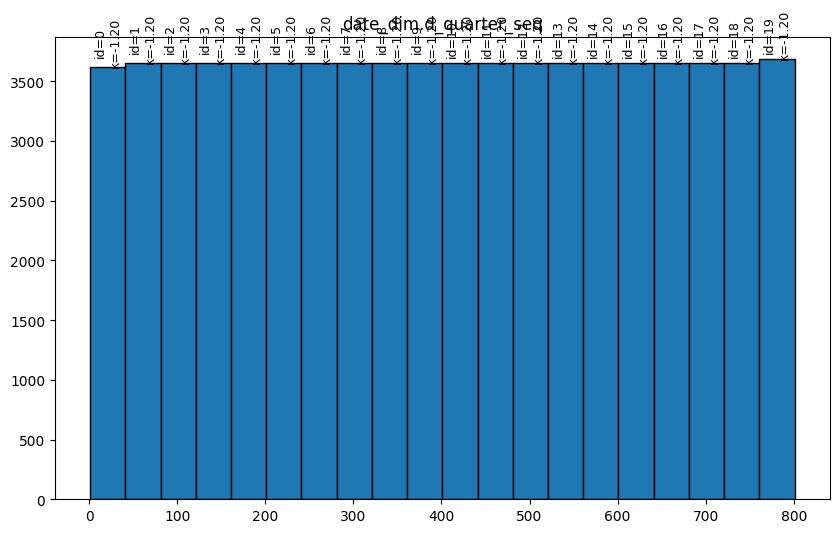

<Figure size 1600x1000 with 0 Axes>

date_dim.d_year
0    1900
1    1900
2    1900
Name: d_year, dtype: int64


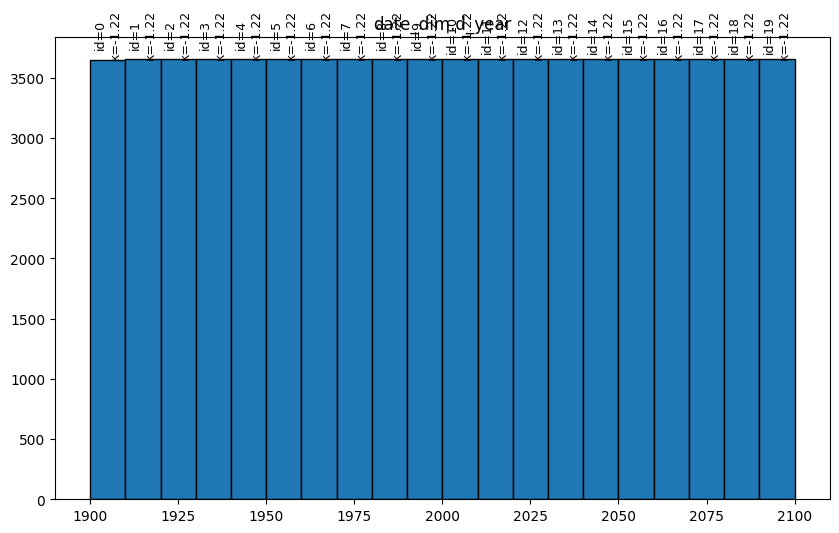

<Figure size 1600x1000 with 0 Axes>

Skipped date_dim.d_dow (not numeric)
Skipped date_dim.d_moy (not numeric)
Skipped date_dim.d_dom (not numeric)
Skipped date_dim.d_qoy (not numeric)
date_dim.d_fy_year
0    1900
1    1900
2    1900
Name: d_fy_year, dtype: int64


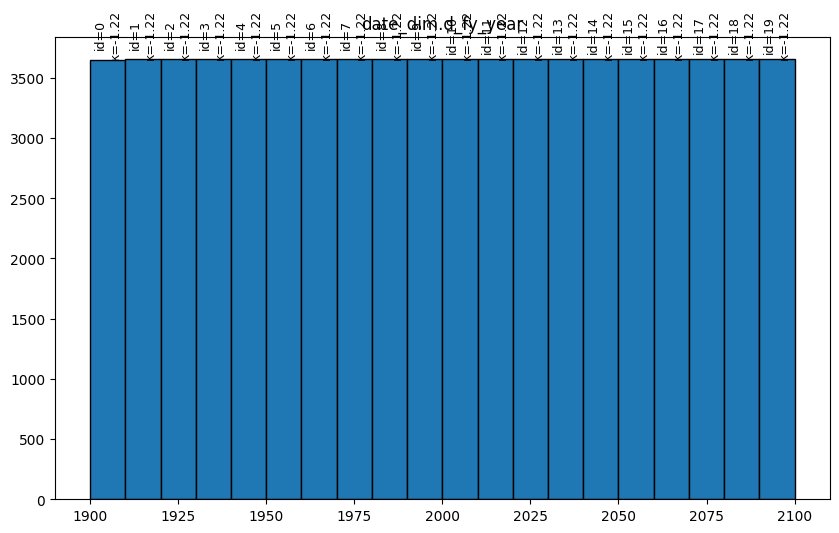

<Figure size 1600x1000 with 0 Axes>

date_dim.d_fy_quarter_seq
0    1
1    1
2    1
Name: d_fy_quarter_seq, dtype: int64


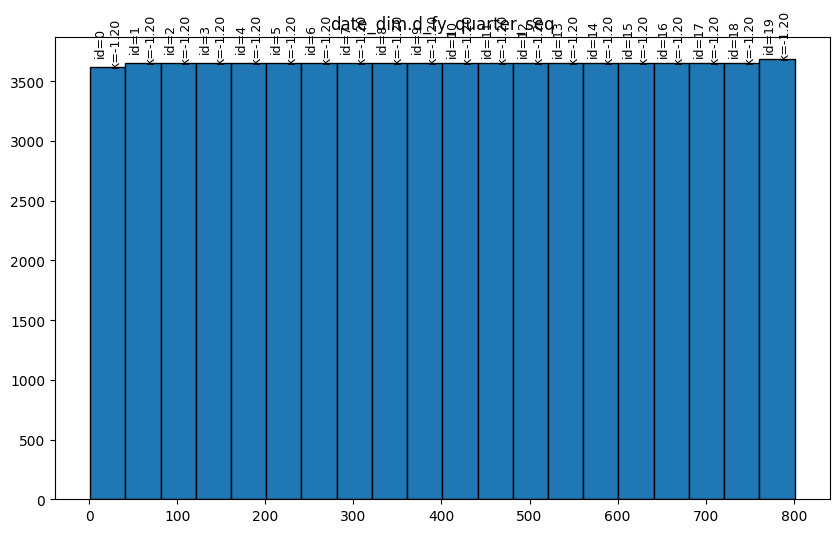

<Figure size 1600x1000 with 0 Axes>

date_dim.d_fy_week_seq
0    1
1    1
2    1
Name: d_fy_week_seq, dtype: int64


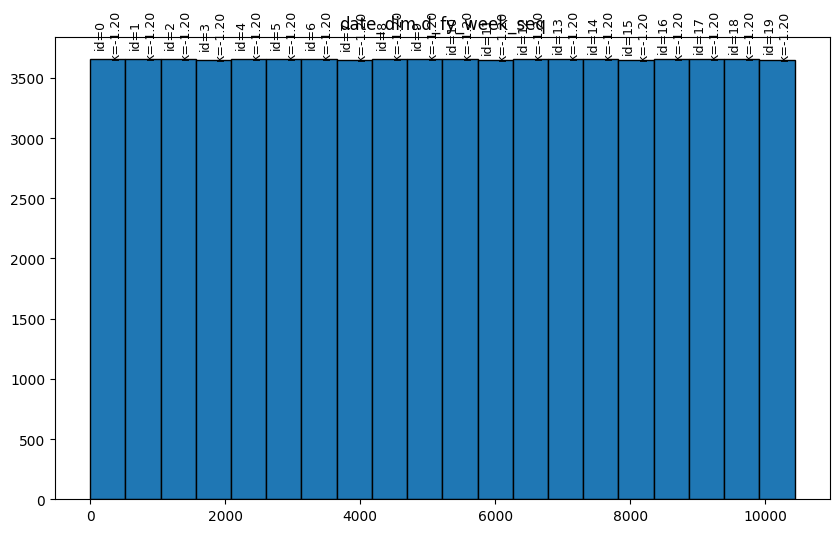

<Figure size 1600x1000 with 0 Axes>

date_dim.d_first_dom
0    2415021
1    2415021
2    2415021
Name: d_first_dom, dtype: int64


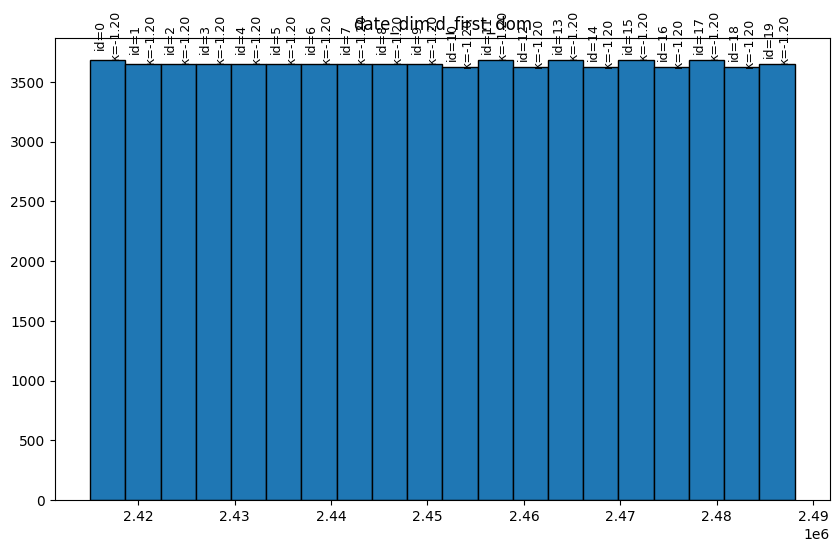

<Figure size 1600x1000 with 0 Axes>

date_dim.d_last_dom
0    2415020
1    2415020
2    2415020
Name: d_last_dom, dtype: int64


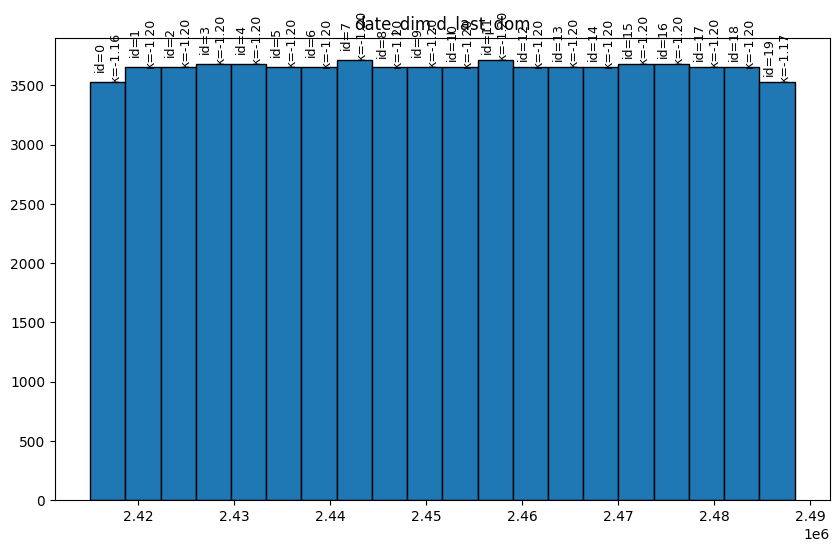

<Figure size 1600x1000 with 0 Axes>

date_dim.d_same_day_ly
0    2414657
1    2414658
2    2414659
Name: d_same_day_ly, dtype: int64


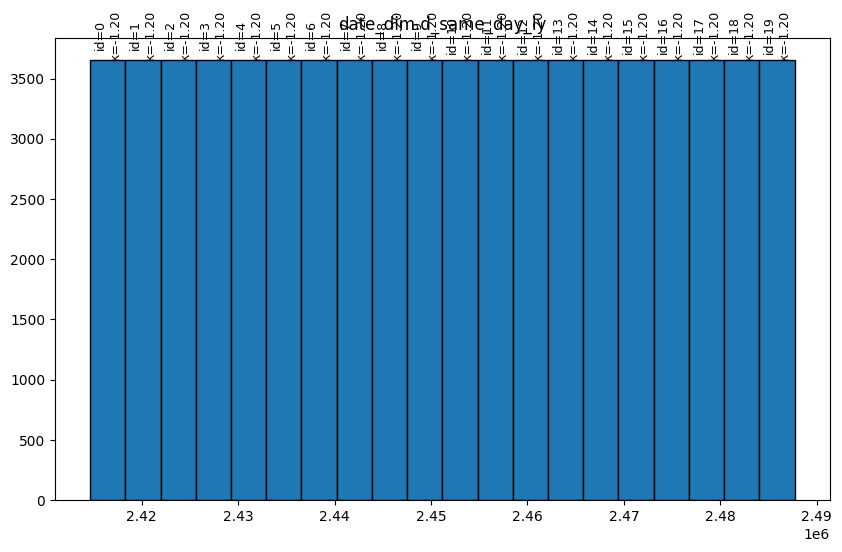

<Figure size 1600x1000 with 0 Axes>

date_dim.d_same_day_lq
0    2414930
1    2414931
2    2414932
Name: d_same_day_lq, dtype: int64


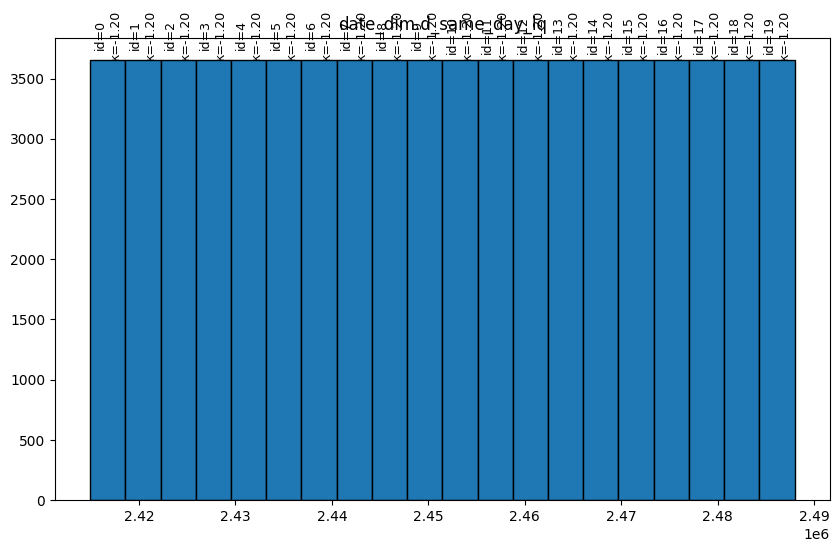

<Figure size 1600x1000 with 0 Axes>

Skipped income_band.ib_income_band_sk (not numeric)
Skipped income_band.ib_lower_bound (not numeric)
Skipped income_band.ib_upper_bound (not numeric)
promotion.p_promo_sk
0    1
1    2
2    3
Name: p_promo_sk, dtype: int64


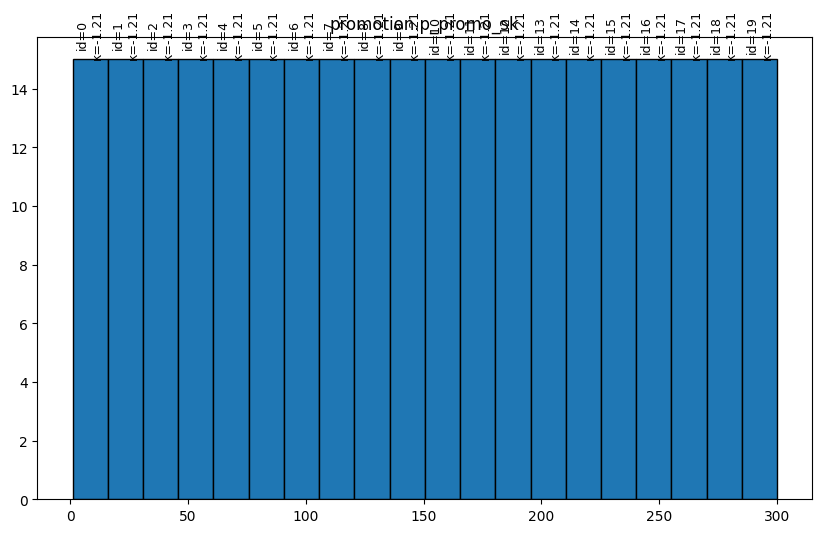

<Figure size 1600x1000 with 0 Axes>

Skipped ship_mode.sm_ship_mode_sk (not numeric)
Skipped store.s_store_sk (not numeric)
Skipped store.s_number_employees (not numeric)
Skipped store.s_floor_space (not numeric)
Skipped store.s_market_id (not numeric)
Skipped store.s_division_id (not numeric)
Skipped store.s_company_id (not numeric)
Skipped store.s_street_number (not numeric)
Skipped store.s_zip (not numeric)
Skipped store.s_gmt_offset (not numeric)
Skipped reason.r_reason_sk (not numeric)
inventory.inv_date_sk
0    2450815
1    2450815
2    2450815
Name: inv_date_sk, dtype: int64


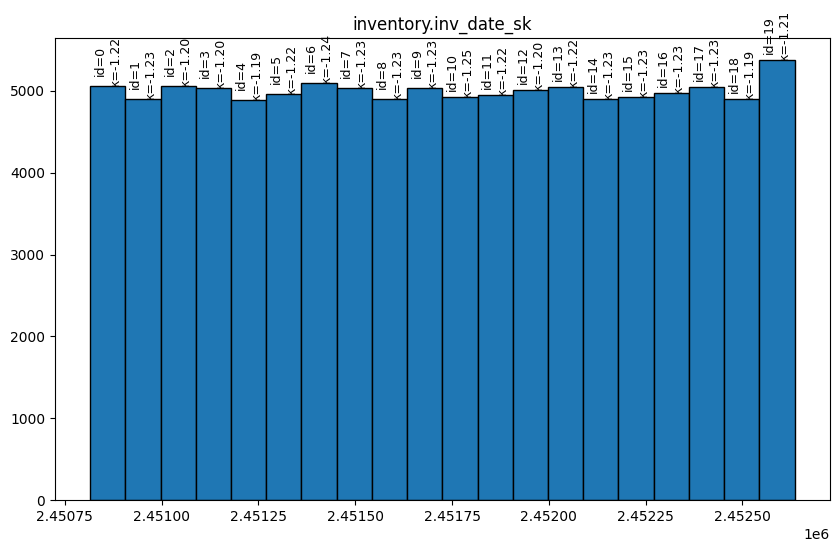

<Figure size 1600x1000 with 0 Axes>

inventory.inv_item_sk
0    1
1    2
2    4
Name: inv_item_sk, dtype: int64


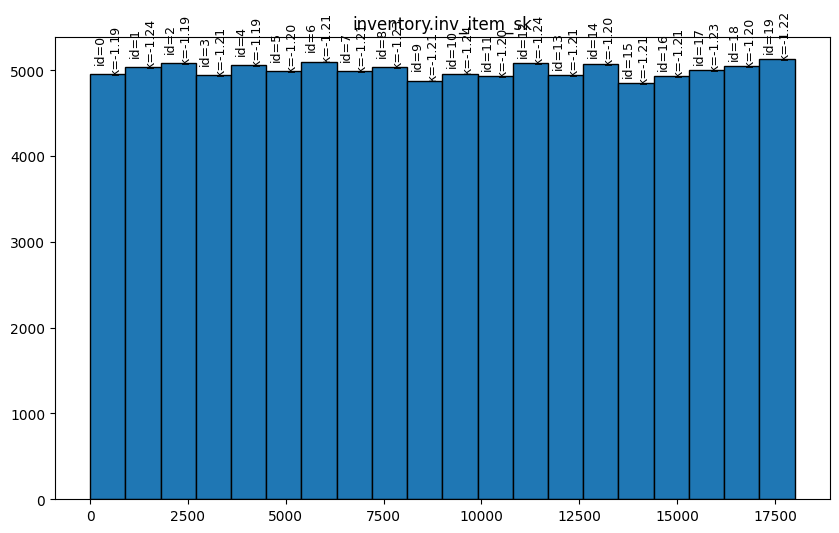

<Figure size 1600x1000 with 0 Axes>

Skipped inventory.inv_warehouse_sk (not numeric)
store_returns.sr_item_sk
0     3302
1    17551
2    12994
Name: sr_item_sk, dtype: int64


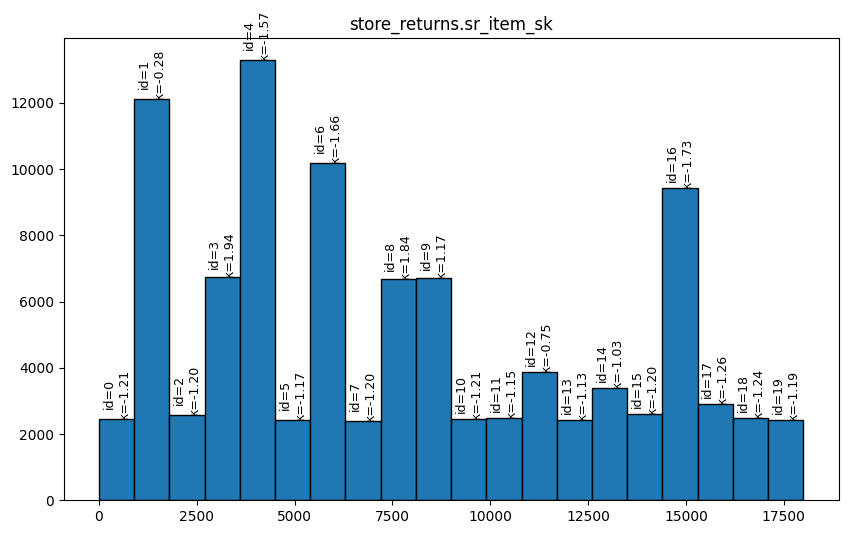

<Figure size 1600x1000 with 0 Axes>

store_returns.sr_ticket_number
0    1
1    1
2    1
Name: sr_ticket_number, dtype: int64


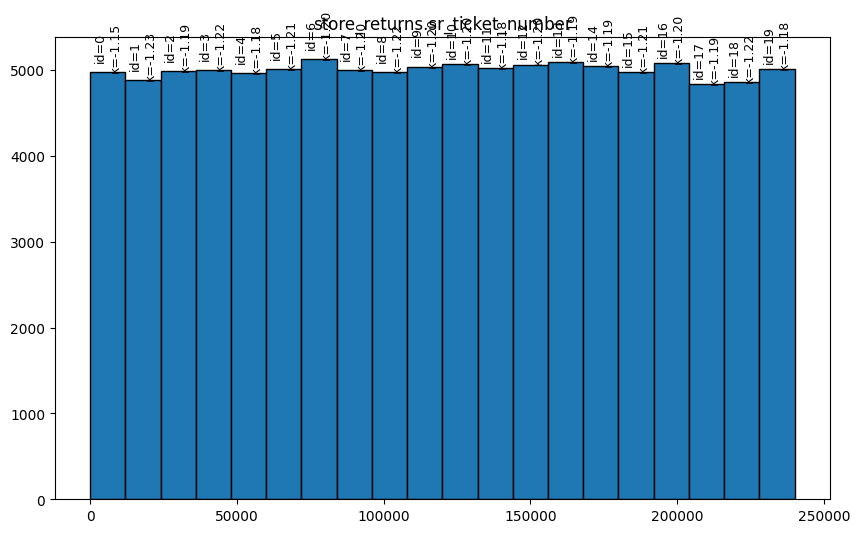

<Figure size 1600x1000 with 0 Axes>

time_dim.t_time_sk
0    0
1    1
2    2
Name: t_time_sk, dtype: int64


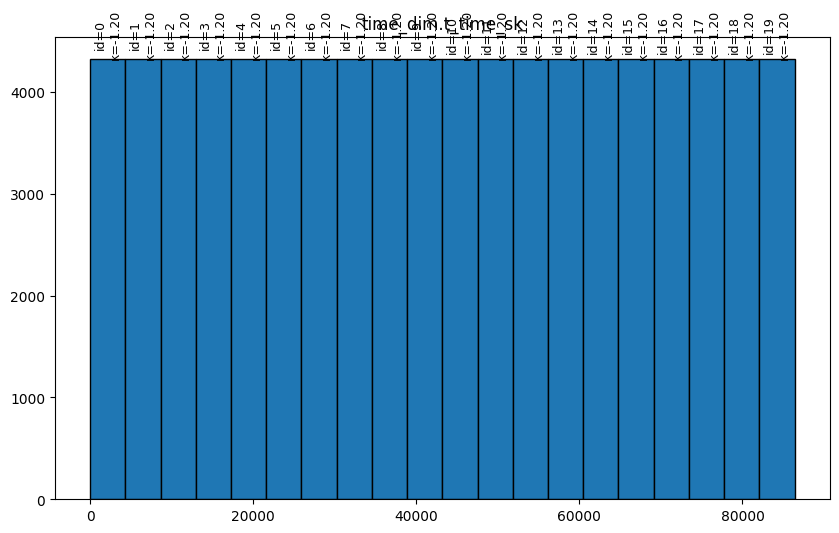

<Figure size 1600x1000 with 0 Axes>

time_dim.t_time
0    0
1    1
2    2
Name: t_time, dtype: int64


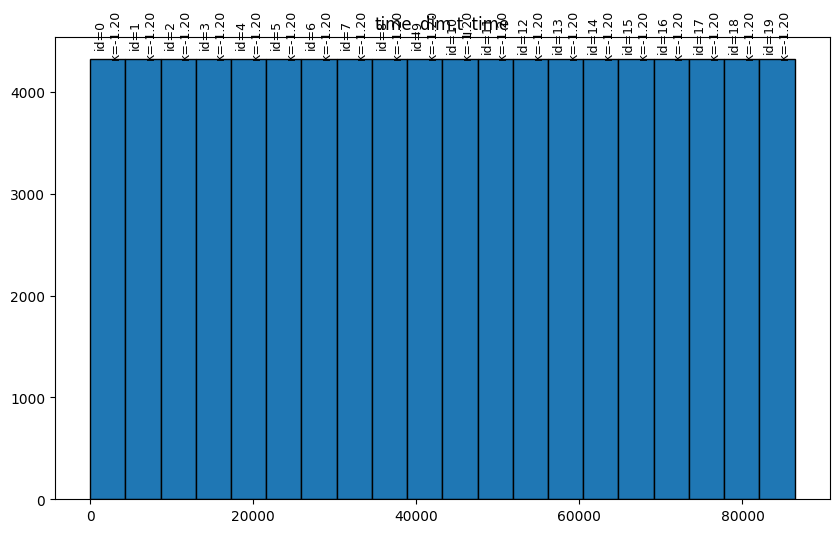

<Figure size 1600x1000 with 0 Axes>

Skipped time_dim.t_hour (not numeric)
time_dim.t_minute
0    0
1    0
2    0
Name: t_minute, dtype: int64


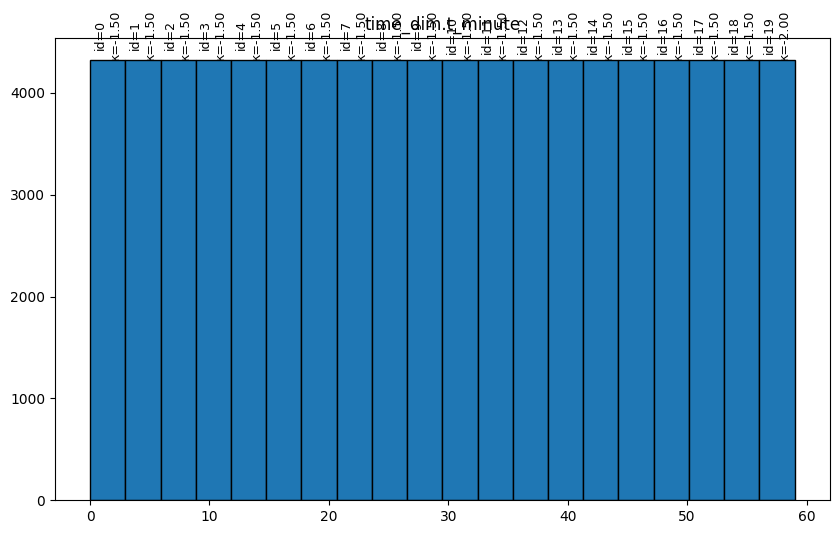

<Figure size 1600x1000 with 0 Axes>

time_dim.t_second
0    0
1    1
2    2
Name: t_second, dtype: int64


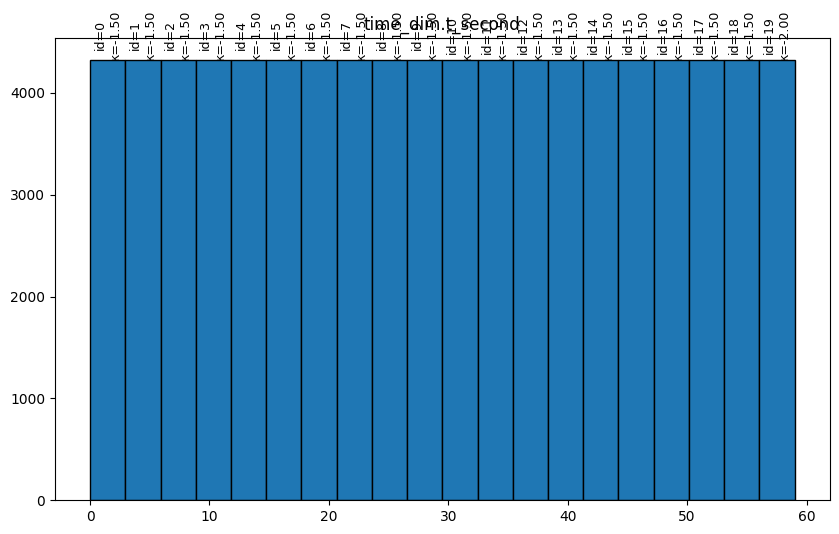

<Figure size 1600x1000 with 0 Axes>

store_sales.ss_item_sk
0    17881
1     3302
2    17551
Name: ss_item_sk, dtype: int64


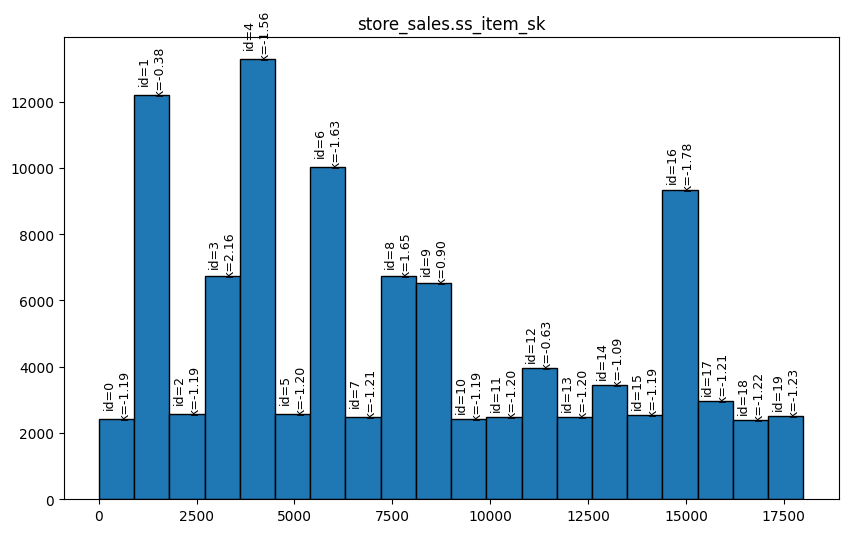

<Figure size 1600x1000 with 0 Axes>

store_sales.ss_ticket_number
0    1
1    1
2    1
Name: ss_ticket_number, dtype: int64


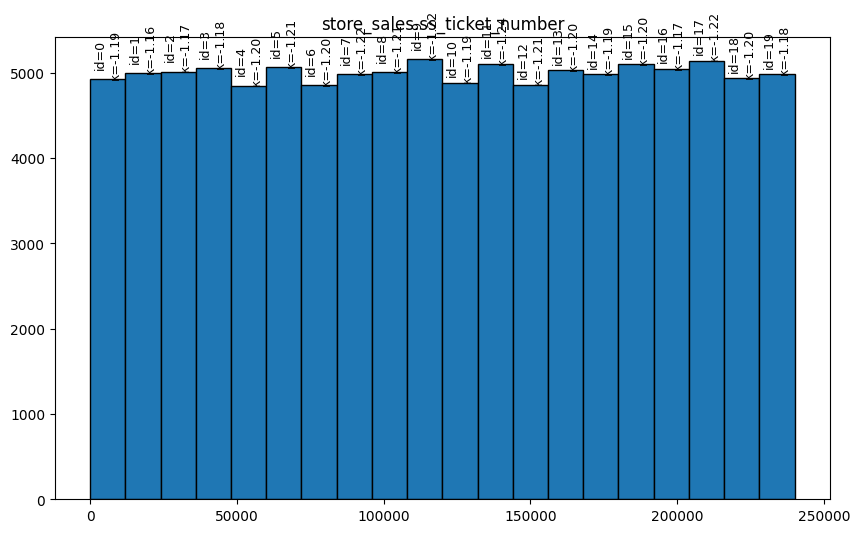

<Figure size 1600x1000 with 0 Axes>

Skipped warehouse.w_warehouse_sk (not numeric)
Skipped warehouse.w_zip (not numeric)
web_page.wp_web_page_sk
0    1
1    2
2    3
Name: wp_web_page_sk, dtype: int64


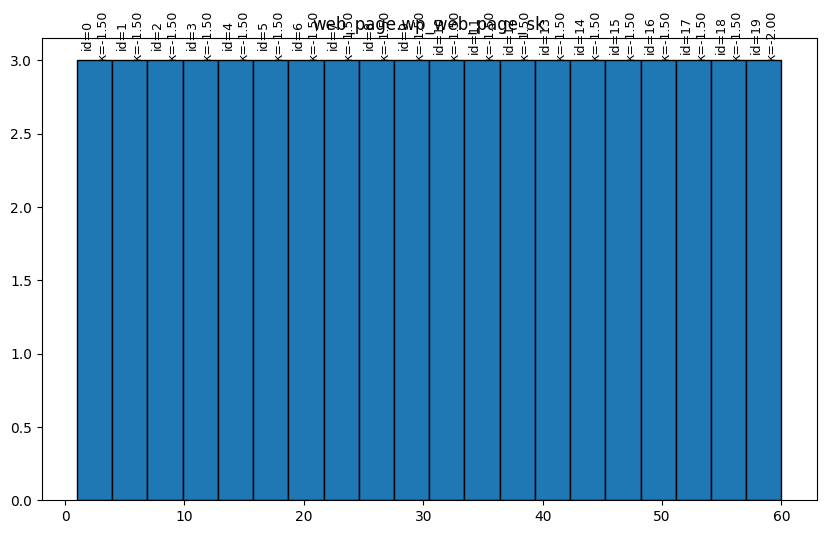

<Figure size 1600x1000 with 0 Axes>

Skipped web_page.wp_access_date_sk (not numeric)
web_returns.wr_item_sk
0     1394
1     7909
2    13436
Name: wr_item_sk, dtype: int64


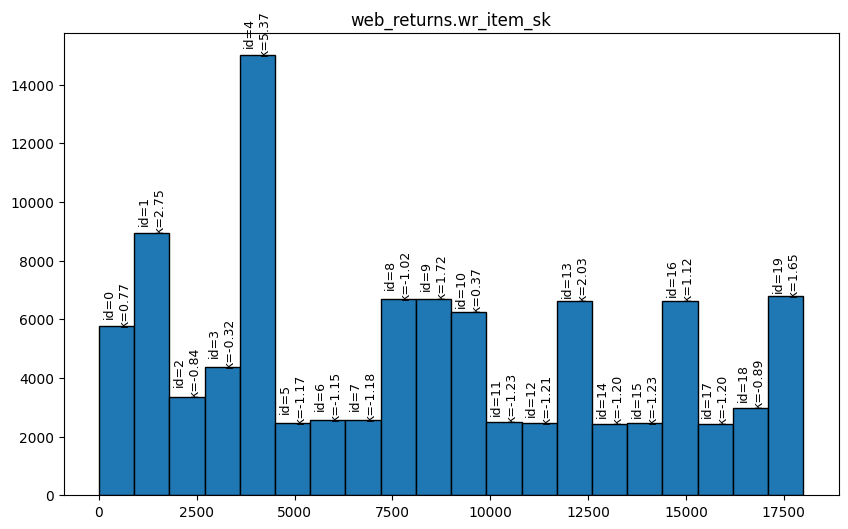

<Figure size 1600x1000 with 0 Axes>

web_returns.wr_order_number
0    1
1    1
2    2
Name: wr_order_number, dtype: int64


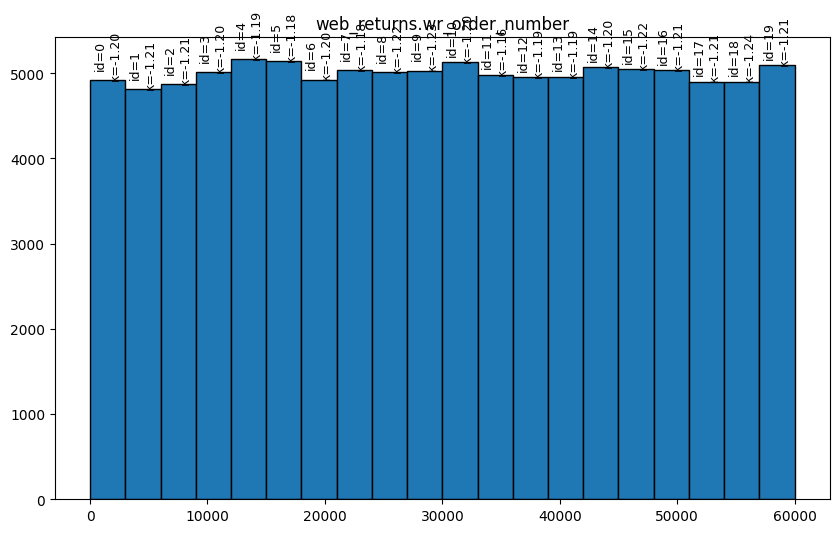

<Figure size 1600x1000 with 0 Axes>

web_sales.ws_item_sk
0    16933
1     3014
2     4645
Name: ws_item_sk, dtype: int64


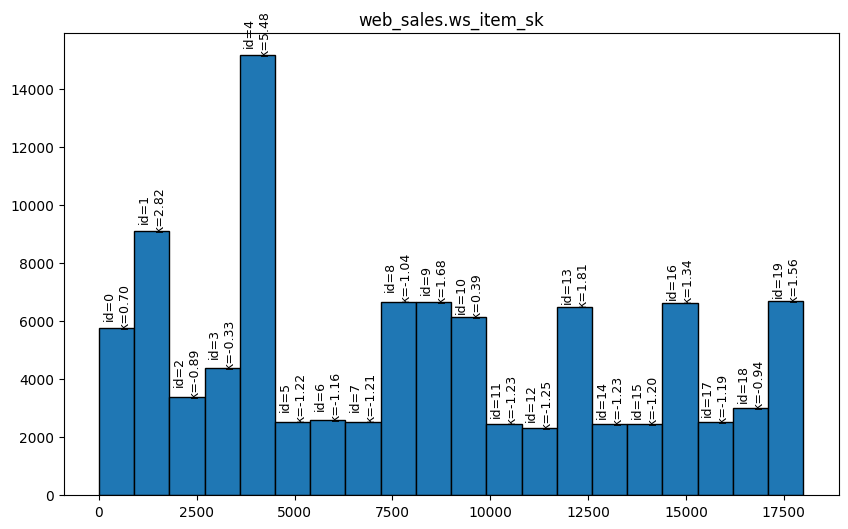

<Figure size 1600x1000 with 0 Axes>

web_sales.ws_order_number
0    1
1    1
2    1
Name: ws_order_number, dtype: int64


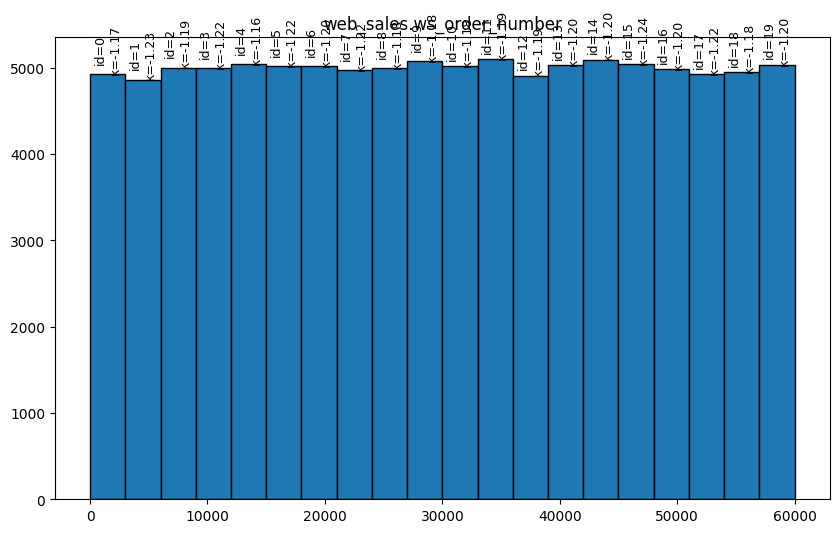

<Figure size 1600x1000 with 0 Axes>

Skipped web_site.web_site_sk (not numeric)
Skipped web_site.web_open_date_sk (not numeric)
Skipped web_site.web_mkt_id (not numeric)
Skipped web_site.web_company_id (not numeric)
Skipped web_site.web_street_number (not numeric)
Skipped web_site.web_zip (not numeric)
Skipped web_site.web_gmt_offset (not numeric)


In [ ]:
from scipy.stats import kurtosis

lst = []
def plot_column(table, col, info):

    typ, data = info

    if not is_numeric_series(data):
        print(f"Skipped {table}.{col} (not numeric)")
        return

    unique_vals = data.nunique()

    if unique_vals < 20:
        print(f"Skipped {table}.{col} (unique values = {unique_vals})")
        return

    plt.figure(figsize=(10,6))

    counts, edges, patches = plt.hist(
        data,
        bins=20,
        edgecolor="black"
    )

    for i, count in enumerate(counts):

        center = (edges[i] + edges[i+1]) / 2

        # значения внутри бакета
        bucket_values = data[(data >= edges[i]) & (data < edges[i+1])]

        if len(bucket_values) > 1:
            b_mean = bucket_values.mean()
            b_std = bucket_values.std()
            b_kurt = kurtosis(bucket_values, fisher=True)
        else:
            b_mean = 0
            b_std = 0
            b_kurt = 0

        plt.text(
            center,
            count,
            f"id={i}\nκ={b_kurt:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=90
        )

    plt.title(f"{table}.{col}")

    plt.figure(figsize=(16,10))

    plt.subplots_adjust(top=0.85)

    plt.figtext(
        0.5,
        0.02,
        f"unique values = {unique_vals}",
        ha="center",
        fontsize=8
    )

    print(f"{table}.{col}")
    print(loaded_dfs[table][col].head(3))

    plt.tight_layout()
    plt.show()


for key, info in prepared.items():
    table, col = key
    plot_column(table, col, info)

добавить curtosis и skewness


In [ ]:
# функция для получения данных колонки

def get_column_data(table, column):

    if table not in loaded_dfs:
        raise ValueError("table not found")

    df = loaded_dfs[table]

    if column not in df.columns:
        raise ValueError("column not found")

    data = df[column].dropna()

    if len(data) > 100000:
        data = data.sample(100000, random_state=42)

    return data

In [ ]:
def plot_histogram_with_buckets(table, column, buckets):

    data = get_column_data(table, column)

    plt.figure(figsize=(12,6))

    counts, edges, patches = plt.hist(
        data,
        bins=buckets,
        edgecolor="black"
    )

    # подписи bucket_id
    for i, count in enumerate(counts):

        center = (edges[i] + edges[i+1]) / 2

        plt.text(
            center,
            count,
            f"{i}",
            ha="center",
            va="bottom",
            fontsize=10,
            color="red"
        )

    plt.title(f"{table}.{column} distribution ({buckets} buckets)")
    plt.xlabel(column)
    plt.ylabel("frequency")

    plt.show()

    return counts, edges

In [ ]:
# drilldown внутри одного бакета

def plot_bucket_detail(table, column, buckets, bucket_id):

    data = get_column_data(table, column)

    counts, edges = np.histogram(data, bins=buckets)

    if bucket_id >= buckets:
        raise ValueError("bucket_id too large")

    left = edges[bucket_id]
    right = edges[bucket_id+1]

    bucket_data = data[(data >= left) & (data < right)]

    plt.figure(figsize=(10,6))

    sns.histplot(bucket_data, bins=20)

    plt.title(
        f"{table}.{column} bucket {bucket_id}\n"
        f"range [{left:.2f}, {right:.2f}]"
    )

    plt.xlabel(column)
    plt.ylabel("frequency")

    plt.show()

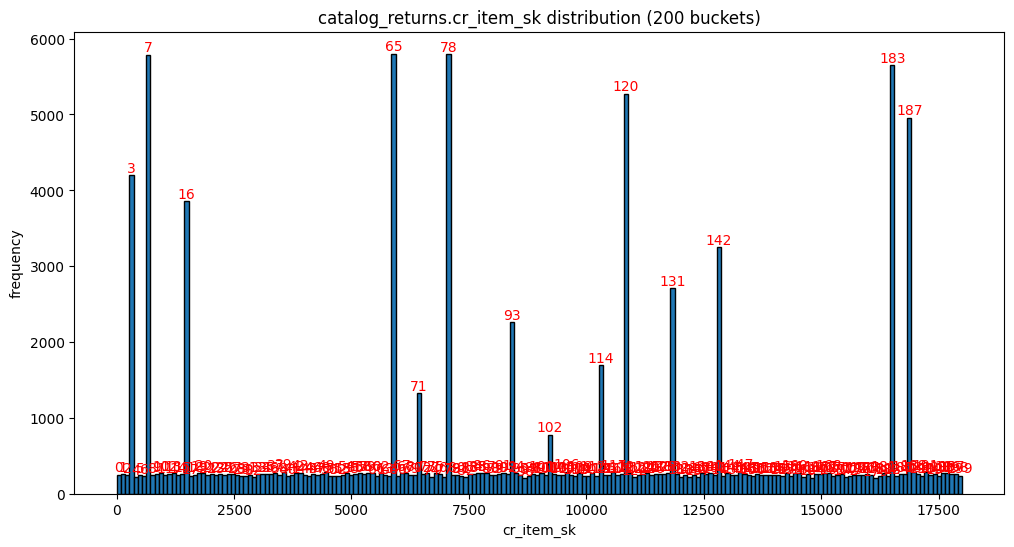

In [ ]:
counts, edges = plot_histogram_with_buckets(
    table="catalog_returns",
    column="cr_item_sk",
    buckets=200
)


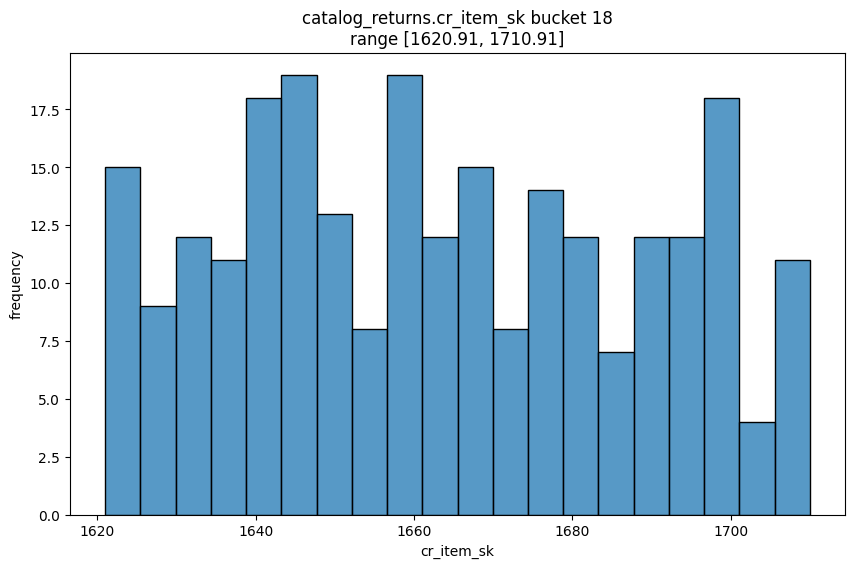

In [ ]:
plot_bucket_detail(
    table="catalog_returns",
    column="cr_item_sk",
    buckets=200,
    bucket_id=18
)

Updates Streams for only targeted values

In [ ]:
# ============================================================
# CONFIG
# ============================================================

# UPDATES_ARCHIVE = "/content/drive/MyDrive/data1gbDBS/data1gbupdates.zip"


TARGET_COLUMNS = {
    'catalog_returns': ['cr_returned_time_sk', 'cr_item_sk'],
    'web_sales':       ['ws_item_sk'],
}

CHECKPOINT_THRESHOLD = 0.05   # 5% изменений → чекпойнт
NUM_STREAMS = 1000            # сколько стримов у нас есть

In [ ]:
# FOR ZIP FILES

# import zipfile
# import tarfile
# import tempfile

# UPDATES_DIR = tempfile.mkdtemp()

# if UPDATES_ARCHIVE.endswith('.zip'):
#     with zipfile.ZipFile(UPDATES_ARCHIVE, 'r') as z:
#         z.extractall(UPDATES_DIR)

# elif UPDATES_ARCHIVE.endswith(('.tar.gz', '.tgz')):
#     with tarfile.open(UPDATES_ARCHIVE, 'r:gz') as t:
#         t.extractall(UPDATES_DIR)

# elif UPDATES_ARCHIVE.endswith('.tar'):
#     with tarfile.open(UPDATES_ARCHIVE, 'r') as t:
#         t.extractall(UPDATES_DIR)

# # Если внутри архива вложенная папка — спускаемся в неё
# subdirs = os.listdir(UPDATES_DIR)
# if len(subdirs) == 1 and os.path.isdir(os.path.join(UPDATES_DIR, subdirs[0])):
#     UPDATES_DIR = os.path.join(UPDATES_DIR, subdirs[0])

# print(f"Extracted to: {UPDATES_DIR}")
# print(f"Files: {len(os.listdir(UPDATES_DIR))}")

Extracted to: /tmp/tmp9tiyfhzm/data1gbupdates
Files: 23000


In [ ]:
import os

UPDATES_DIR = "./dsb/code/tools/data1gbupdates"

TARGET_COLUMNS = {
    'catalog_returns': ['cr_returned_time_sk', 'cr_item_sk'],
    'web_sales':       ['ws_item_sk'],
}

CHECKPOINT_THRESHOLD = 0.05
NUM_STREAMS = 1000

if not os.path.isdir(UPDATES_DIR):
    raise FileNotFoundError(f"Directory not found: {UPDATES_DIR}")

print(f"Using updates dir: {UPDATES_DIR}")
print(f"Files: {len(os.listdir(UPDATES_DIR))}")

In [ ]:
# ============================================================
# targeted_loaded_dfs — только интересующие колонки
# ============================================================

def extract_targeted(loaded_dfs):
    """Извлекает целевые колонки из loaded_dfs."""
    targeted = {}
    for table, cols in TARGET_COLUMNS.items():
        for col in cols:
            key = f"{table}.{col}"
            targeted[key] = loaded_dfs[table][col].dropna().reset_index(drop=True).copy()
    return targeted


targeted_loaded_dfs = extract_targeted(loaded_dfs)

print("=== targeted_loaded_dfs (initial) ===")
for key, series in targeted_loaded_dfs.items():
    print(f"  {key:45s}  {len(series):>10,} values   "
          f"range [{series.min()}, {series.max()}]")

=== targeted_loaded_dfs (initial) ===
  catalog_returns.cr_returned_time_sk               214,842 values   range [2, 86398]
  catalog_returns.cr_item_sk                        214,842 values   range [1, 18000]
  web_sales.ws_item_sk                              717,680 values   range [1, 18000]


In [ ]:
# ============================================================
# Staging file definitions & loader
# ============================================================

STAGING_COLS = {
    'delete': ['del_date_start', 'del_date_end'],
    'inventory_delete': ['del_date_start', 'del_date_end'],
    's_catalog_returns': [
        'cret_call_center_id', 'cret_order_id', 'cret_line_number',
        'cret_item_id', 'cret_return_customer_id', 'cret_refund_customer_id',
        'cret_return_date', 'cret_return_time',
        'cret_return_qty', 'cret_return_amt', 'cret_return_tax',
        'cret_return_fee', 'cret_return_ship_cost',
        'cret_refunded_cash', 'cret_reversed_charge',
        'cret_merchant_credit', 'cret_reason_id',
        'cret_shipmode_id', 'cret_catalog_page_id', 'cret_warehouse_id'
    ],
    's_web_order': [
        'word_order_id', 'word_bill_customer_id', 'word_ship_customer_id',
        'word_order_date', 'word_order_time',
        'word_ship_mode_id', 'word_web_site_id', 'word_comment'
    ],
    's_web_order_lineitem': [
        'wlin_order_id', 'wlin_line_number', 'wlin_item_id',
        'wlin_promotion_id', 'wlin_quantity', 'wlin_sales_price',
        'wlin_coupon_amt', 'wlin_warehouse_id', 'wlin_ship_date',
        'wlin_ship_cost', 'wlin_web_page_id'
    ],
}


def load_staging(filepath, columns):
    if not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath, sep='|', header=None, engine='python')
    if df.iloc[:, -1].isna().all():
        df = df.iloc[:, :-1]
    if len(df.columns) > len(columns):
        df = df.iloc[:, :len(columns)]
    if len(df.columns) < len(columns):
        for _ in range(len(columns) - len(df.columns)):
            df[df.shape[1]] = None
    df.columns = columns
    return df

In [ ]:
# ============================================================
# Dimension key lookups
# ============================================================

def lookup_date_sks_in_range(date_dim, date_start, date_end):
    """Возвращает set d_date_sk для дат в [start, end]."""
    dd = date_dim[['d_date_sk', 'd_date']].copy()
    dd['d_date'] = pd.to_datetime(dd['d_date'], errors='coerce')
    start = pd.to_datetime(date_start)
    end = pd.to_datetime(date_end)
    mask = (dd['d_date'] >= start) & (dd['d_date'] <= end)
    return set(dd.loc[mask, 'd_date_sk'].values)


def lookup_sk(dim_df, bk_col, sk_col, keys, scd2_end_col=None):
    """business_key → surrogate_key."""
    dim = dim_df.copy()
    if scd2_end_col and scd2_end_col in dim.columns:
        dim = dim[dim[scd2_end_col].isna()]
    if dim[bk_col].dtype == object:
        dim[bk_col] = dim[bk_col].str.strip()
    if keys.dtype == object:
        keys = keys.str.strip()
    mapping = dim.drop_duplicates(bk_col, keep='last').set_index(bk_col)[sk_col]
    return keys.map(mapping)


def lookup_date_sk(date_dim, dates):
    dates = pd.to_datetime(dates, errors='coerce')
    mapping = date_dim.drop_duplicates('d_date').set_index('d_date')['d_date_sk']
    mapping.index = pd.to_datetime(mapping.index, errors='coerce')
    return dates.map(mapping)


def lookup_time_sk(time_dim, times):
    times = pd.to_numeric(times, errors='coerce')
    mapping = time_dim.drop_duplicates('t_time').set_index('t_time')['t_time_sk']
    return times.map(mapping)

In [ ]:
# ============================================================
# Refresh operations (only tables we care about)
# ============================================================

def apply_deletes_targeted(stream_id, updates_dir, loaded_dfs):
    """Удаляет строки из catalog_returns и web_sales по date range."""

    del_path = os.path.join(updates_dir, f'delete_{stream_id}.dat')
    del_df = load_staging(del_path, STAGING_COLS['delete'])
    if del_df is None:
        return {}

    del_df['del_date_start'] = pd.to_datetime(del_df['del_date_start'])
    del_df['del_date_end'] = pd.to_datetime(del_df['del_date_end'])

    date_dim = loaded_dfs['date_dim']
    delete_sks = set()
    for _, row in del_df.iterrows():
        delete_sks |= lookup_date_sks_in_range(
            date_dim, row['del_date_start'], row['del_date_end']
        )

    stats = {}

    # catalog_returns
    table = 'catalog_returns'
    date_col = 'cr_returned_date_sk'
    before = len(loaded_dfs[table])
    loaded_dfs[table] = loaded_dfs[table][
        ~loaded_dfs[table][date_col].isin(delete_sks)
    ].reset_index(drop=True)
    deleted = before - len(loaded_dfs[table])
    stats[table] = {'deleted': deleted}
    print(f"    DELETE {table}: -{deleted} rows")

    # web_sales
    table = 'web_sales'
    date_col = 'ws_sold_date_sk'
    before = len(loaded_dfs[table])
    loaded_dfs[table] = loaded_dfs[table][
        ~loaded_dfs[table][date_col].isin(delete_sks)
    ].reset_index(drop=True)
    deleted = before - len(loaded_dfs[table])
    stats[table] = {'deleted': deleted}
    print(f"    DELETE {table}: -{deleted} rows")

    return stats


def insert_catalog_returns_targeted(stream_id, updates_dir, loaded_dfs):
    """Вставляет новые catalog_returns."""

    path = os.path.join(updates_dir, f's_catalog_returns_{stream_id}.dat')
    cr = load_staging(path, STAGING_COLS['s_catalog_returns'])
    if cr is None:
        return 0

    item = loaded_dfs['item']
    date_dim = loaded_dfs['date_dim']
    time_dim = loaded_dfs['time_dim']
    customer = loaded_dfs['customer']

    new = pd.DataFrame()

    # --- Ключевые колонки ---
    new['cr_returned_date_sk'] = lookup_date_sk(date_dim, cr['cret_return_date'])

    # time: "HH:MM:SS" → seconds since midnight → t_time_sk
    def time_str_to_seconds(t):
        try:
            parts = str(t).split(':')
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
        except:
            return np.nan
    time_seconds = cr['cret_return_time'].apply(time_str_to_seconds)
    new['cr_returned_time_sk'] = lookup_time_sk(time_dim, time_seconds)

    new['cr_item_sk'] = lookup_sk(item, 'i_item_id', 'i_item_sk',
                                  cr['cret_item_id'], 'i_rec_end_date')

    # --- Остальные колонки ---
    cmap = customer.drop_duplicates('c_customer_id', keep='last').copy()
    if cmap['c_customer_id'].dtype == object:
        cmap['c_customer_id'] = cmap['c_customer_id'].str.strip()
    cmap = cmap.set_index('c_customer_id')

    for prefix, src in [('cr_refunded', 'cret_refund_customer_id'),
                        ('cr_returning', 'cret_return_customer_id')]:
        cid = cr[src].str.strip()
        new[f'{prefix}_customer_sk'] = lookup_sk(customer, 'c_customer_id',
                                                  'c_customer_sk', cr[src])
        new[f'{prefix}_cdemo_sk'] = cid.map(cmap['c_current_cdemo_sk']).values
        new[f'{prefix}_hdemo_sk'] = cid.map(cmap['c_current_hdemo_sk']).values
        new[f'{prefix}_addr_sk']  = cid.map(cmap['c_current_addr_sk']).values

    new['cr_call_center_sk'] = lookup_sk(
        loaded_dfs['call_center'], 'cc_call_center_id', 'cc_call_center_sk',
        cr['cret_call_center_id'])
    new['cr_catalog_page_sk'] = None
    new['cr_ship_mode_sk'] = lookup_sk(
        loaded_dfs['ship_mode'], 'sm_ship_mode_id', 'sm_ship_mode_sk',
        cr['cret_shipmode_id'])
    new['cr_warehouse_sk'] = lookup_sk(
        loaded_dfs['warehouse'], 'w_warehouse_id', 'w_warehouse_sk',
        cr['cret_warehouse_id'])
    new['cr_reason_sk'] = lookup_sk(
        loaded_dfs['reason'], 'r_reason_id', 'r_reason_sk',
        cr['cret_reason_id'])

    new['cr_order_number']      = cr['cret_order_id'].values
    new['cr_return_quantity']    = pd.to_numeric(cr['cret_return_qty'], errors='coerce').values
    new['cr_return_amount']      = pd.to_numeric(cr['cret_return_amt'], errors='coerce').values
    new['cr_return_tax']         = pd.to_numeric(cr['cret_return_tax'], errors='coerce').values
    new['cr_return_amt_inc_tax'] = new['cr_return_amount'] + new['cr_return_tax']
    new['cr_fee']                = pd.to_numeric(cr['cret_return_fee'], errors='coerce').values
    new['cr_return_ship_cost']   = pd.to_numeric(cr['cret_return_ship_cost'], errors='coerce').values
    new['cr_refunded_cash']      = pd.to_numeric(cr['cret_refunded_cash'], errors='coerce').values
    new['cr_reversed_charge']    = pd.to_numeric(cr['cret_reversed_charge'], errors='coerce').values
    new['cr_store_credit']       = pd.to_numeric(cr['cret_merchant_credit'], errors='coerce').values
    new['cr_net_loss'] = new['cr_fee'] + new['cr_return_ship_cost'] \
                         - new['cr_refunded_cash'] - new['cr_reversed_charge'] \
                         - new['cr_store_credit']

    n_new = len(new)
    loaded_dfs['catalog_returns'] = pd.concat(
        [loaded_dfs['catalog_returns'], new], ignore_index=True
    )
    print(f"    INSERT catalog_returns: +{n_new} rows")
    return n_new


def insert_web_sales_targeted(stream_id, updates_dir, loaded_dfs):
    """Вставляет новые web_sales."""

    o_path = os.path.join(updates_dir, f's_web_order_{stream_id}.dat')
    l_path = os.path.join(updates_dir, f's_web_order_lineitem_{stream_id}.dat')
    order = load_staging(o_path, STAGING_COLS['s_web_order'])
    line  = load_staging(l_path, STAGING_COLS['s_web_order_lineitem'])
    if order is None or line is None:
        return 0

    merged = line.merge(order, left_on='wlin_order_id',
                        right_on='word_order_id', how='inner')

    date_dim  = loaded_dfs['date_dim']
    time_dim  = loaded_dfs['time_dim']
    item      = loaded_dfs['item']
    customer  = loaded_dfs['customer']
    ship_mode = loaded_dfs['ship_mode']
    warehouse = loaded_dfs['warehouse']
    web_site  = loaded_dfs['web_site']
    web_page  = loaded_dfs['web_page']
    promo     = loaded_dfs['promotion']

    new = pd.DataFrame()
    new['ws_sold_date_sk'] = lookup_date_sk(date_dim, merged['word_order_date'])
    new['ws_sold_time_sk'] = lookup_time_sk(time_dim, merged['word_order_time'])
    new['ws_ship_date_sk'] = lookup_date_sk(date_dim, merged['wlin_ship_date'])
    new['ws_item_sk']      = lookup_sk(item, 'i_item_id', 'i_item_sk',
                                       merged['wlin_item_id'], 'i_rec_end_date')

    cmap = customer.drop_duplicates('c_customer_id', keep='last').copy()
    if cmap['c_customer_id'].dtype == object:
        cmap['c_customer_id'] = cmap['c_customer_id'].str.strip()
    cmap = cmap.set_index('c_customer_id')

    for prefix, src in [('ws_bill', 'word_bill_customer_id'),
                        ('ws_ship', 'word_ship_customer_id')]:
        cid = merged[src].str.strip()
        new[f'{prefix}_customer_sk'] = lookup_sk(customer, 'c_customer_id',
                                                  'c_customer_sk', merged[src])
        new[f'{prefix}_cdemo_sk'] = cid.map(cmap['c_current_cdemo_sk']).values
        new[f'{prefix}_hdemo_sk'] = cid.map(cmap['c_current_hdemo_sk']).values
        new[f'{prefix}_addr_sk']  = cid.map(cmap['c_current_addr_sk']).values

    new['ws_web_page_sk']  = lookup_sk(web_page, 'wp_web_page_id', 'wp_web_page_sk',
                                       merged['wlin_web_page_id'], 'wp_rec_end_date')
    new['ws_web_site_sk']  = lookup_sk(web_site, 'web_site_id', 'web_site_sk',
                                       merged['word_web_site_id'], 'web_rec_end_date')
    new['ws_ship_mode_sk'] = lookup_sk(ship_mode, 'sm_ship_mode_id', 'sm_ship_mode_sk',
                                       merged['word_ship_mode_id'])
    new['ws_warehouse_sk'] = lookup_sk(warehouse, 'w_warehouse_id', 'w_warehouse_sk',
                                       merged['wlin_warehouse_id'])
    new['ws_promo_sk']     = lookup_sk(promo, 'p_promo_id', 'p_promo_sk',
                                       merged['wlin_promotion_id'])
    new['ws_order_number'] = merged['word_order_id'].values

    qty    = pd.to_numeric(merged['wlin_quantity'], errors='coerce').fillna(0)
    price  = pd.to_numeric(merged['wlin_sales_price'], errors='coerce').fillna(0)
    coupon = pd.to_numeric(merged['wlin_coupon_amt'], errors='coerce').fillna(0)
    ship_c = pd.to_numeric(merged['wlin_ship_cost'], errors='coerce').fillna(0)

    item_cur = item[item['i_rec_end_date'].isna()].drop_duplicates('i_item_id', keep='last').copy()
    if item_cur['i_item_id'].dtype == object:
        item_cur['i_item_id'] = item_cur['i_item_id'].str.strip()
    imap = item_cur.set_index('i_item_id')
    iid = merged['wlin_item_id'].str.strip()
    wholesale  = iid.map(imap['i_wholesale_cost']).astype(float).fillna(0)
    list_price = iid.map(imap['i_current_price']).astype(float).fillna(0)

    new['ws_quantity']           = qty.values
    new['ws_wholesale_cost']     = wholesale.values
    new['ws_list_price']         = list_price.values
    new['ws_sales_price']        = price.values
    new['ws_ext_discount_amt']   = (list_price.values - price.values) * qty.values
    new['ws_ext_sales_price']    = (price * qty).values
    new['ws_ext_wholesale_cost'] = (wholesale * qty).values
    new['ws_ext_list_price']     = (list_price * qty).values
    net_paid = (price * qty - coupon).values
    new['ws_coupon_amt']              = coupon.values
    new['ws_ext_ship_cost']           = ship_c.values
    new['ws_net_paid']                = net_paid
    new['ws_ext_tax']                 = net_paid * 0.07
    new['ws_net_paid_inc_tax']        = net_paid * 1.07
    new['ws_net_paid_inc_ship']       = net_paid + ship_c.values
    new['ws_net_paid_inc_ship_tax']   = net_paid * 1.07 + ship_c.values
    new['ws_net_profit']              = net_paid - (wholesale * qty).values

    n_new = len(new)
    loaded_dfs['web_sales'] = pd.concat(
        [loaded_dfs['web_sales'], new], ignore_index=True
    )
    print(f"    INSERT web_sales: +{n_new} rows")
    return n_new

In [ ]:
class CheckpointManager:

    def __init__(self, targeted_loaded_dfs):
        self.keys = list(targeted_loaded_dfs.keys())

        # Пороги: 5, 10, 15, ..., 100
        self.thresholds = list(range(5, 105, 5))  # [5, 10, ..., 100]

        # Per-column state
        self.baseline_counts = {}
        self.cumulative_churn = {}
        self.next_threshold_idx = {}
        self.checkpoints = {}
        self.change_log = []

        for key in self.keys:
            series = targeted_loaded_dfs[key]
            self.baseline_counts[key] = len(series)
            self.cumulative_churn[key] = 0
            self.next_threshold_idx[key] = 0  # индекс в self.thresholds

            # 21 чекпойнтов: initial + 20 порогов
            self.checkpoints[key] = {
                'initial': series.copy()
            }

        self._print_init()

    def _print_init(self):
        print("💾 CHECKPOINT 'initial' saved for all columns")
        for key in self.keys:
            print(f"    {key}: {self.baseline_counts[key]:,} values")
        print(f"\n  Thresholds: {self.thresholds}%")
        print(f"  Target: 21 checkpoints per column (initial + 20)\n")

    def add_churn(self, deleted, inserted):
        col_to_table = {
            'catalog_returns.cr_returned_time_sk': 'catalog_returns',
            'catalog_returns.cr_item_sk':          'catalog_returns',
            'web_sales.ws_item_sk':                'web_sales',
        }
        for key in self.keys:
            table = col_to_table[key]
            d = deleted.get(table, 0)
            i = inserted.get(table, 0)
            self.cumulative_churn[key] += d + i

    def check_and_save(self, stream_id, targeted_loaded_dfs):
        saved_any = False

        for key in self.keys:
            # Уже собрали все 20 порогов?
            if self.next_threshold_idx[key] >= len(self.thresholds):
                continue

            baseline = self.baseline_counts[key]
            if baseline == 0:
                continue

            churn_pct = self.cumulative_churn[key] / baseline * 100
            target_pct = self.thresholds[self.next_threshold_idx[key]]

            # Может перепрыгнуть несколько порогов за один стрим
            while (self.next_threshold_idx[key] < len(self.thresholds) and
                   churn_pct >= self.thresholds[self.next_threshold_idx[key]]):

                t = self.thresholds[self.next_threshold_idx[key]]
                label = f'churn_{t}pct'

                self.checkpoints[key][label] = targeted_loaded_dfs[key].copy()
                self.next_threshold_idx[key] += 1
                saved_any = True

                print(f"  💾 {key}: checkpoint '{label}' "
                      f"(stream {stream_id}, actual churn {churn_pct:.1f}%, "
                      f"rows: {len(targeted_loaded_dfs[key]):,})")

        # Log
        self.change_log.append({
            'stream_id': stream_id,
            **{f'{k}_churn_pct': self.cumulative_churn[k] / self.baseline_counts[k] * 100
               for k in self.keys},
            **{f'{k}_rows': len(targeted_loaded_dfs[k]) for k in self.keys},
            **{f'{k}_checkpoints_done': len(self.checkpoints[k]) - 1
               for k in self.keys},
        })

        return saved_any

    def all_complete(self):
        """Все колонки собрали все 20 порогов?"""
        return all(
            self.next_threshold_idx[k] >= len(self.thresholds)
            for k in self.keys
        )

    def progress(self):
        print(f"\n  📊 Progress:")
        for key in self.keys:
            done = len(self.checkpoints[key]) - 1  # minus initial
            total = len(self.thresholds)
            baseline = self.baseline_counts[key]
            churn_pct = self.cumulative_churn[key] / baseline * 100 if baseline else 0
            next_t = (self.thresholds[self.next_threshold_idx[key]]
                      if self.next_threshold_idx[key] < len(self.thresholds) else '✅ DONE')
            print(f"    {key}")
            print(f"      checkpoints: {done}/{total}  |  "
                  f"churn: {churn_pct:.1f}%  |  next: {next_t}")

    def summary(self):
        print(f"\n{'='*65}")
        print(f"  CHECKPOINT SUMMARY")
        print(f"{'='*65}")

        for key in self.keys:
            print(f"\n  {key}:")
            print(f"  {'label':20s} {'rows':>10s} {'Δ vs initial':>14s}")
            print(f"  {'-'*46}")
            initial_n = len(self.checkpoints[key]['initial'])
            for label, series in self.checkpoints[key].items():
                n = len(series)
                delta = n - initial_n
                pct = delta / initial_n * 100 if initial_n else 0
                print(f"  {label:20s} {n:>10,} {delta:>+10,} ({pct:>+.1f}%)")

        log_df = pd.DataFrame(self.change_log)
        return log_df

In [ ]:
ckpt = CheckpointManager(targeted_loaded_dfs)

for stream_id in range(1, NUM_STREAMS + 1):

    # Все колонки достигли 100%?
    if ckpt.all_complete():
        print(f"\n🎉 All columns reached 100% churn at stream {stream_id - 1}!")
        break

    deleted = {}
    inserted = {}

    # 1. Deletes
    del_stats = apply_deletes_targeted(stream_id, UPDATES_DIR, loaded_dfs)
    for table, info in del_stats.items():
        deleted[table] = info['deleted']

    # 2. Inserts
    n_cr = insert_catalog_returns_targeted(stream_id, UPDATES_DIR, loaded_dfs)
    inserted['catalog_returns'] = n_cr

    n_ws = insert_web_sales_targeted(stream_id, UPDATES_DIR, loaded_dfs)
    inserted['web_sales'] = n_ws

    # 3. Update targeted
    targeted_loaded_dfs = extract_targeted(loaded_dfs)

    # 4. Track churn + checkpoint
    ckpt.add_churn(deleted, inserted)
    ckpt.check_and_save(stream_id, targeted_loaded_dfs)

    # Прогресс каждые 50 стримов
    if stream_id % 50 == 0:
        ckpt.progress()

# Финальный прогресс
ckpt.progress()
log_df = ckpt.summary()

💾 CHECKPOINT 'initial' saved for all columns
    catalog_returns.cr_returned_time_sk: 216,989 values
    catalog_returns.cr_item_sk: 216,989 values
    web_sales.ws_item_sk: 726,812 values

  Thresholds: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]%
  Target: 21 checkpoints per column (initial + 20)

    DELETE catalog_returns: -24 rows
    DELETE web_sales: -1848 rows


/tmp/ipykernel_470/3765758268.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  loaded_dfs['catalog_returns'] = pd.concat(


    INSERT catalog_returns: +357 rows
    INSERT web_sales: +1848 rows
    DELETE catalog_returns: -32 rows
    DELETE web_sales: -1992 rows


/tmp/ipykernel_470/3765758268.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  loaded_dfs['catalog_returns'] = pd.concat(


    INSERT catalog_returns: +392 rows
    INSERT web_sales: +1992 rows
    DELETE catalog_returns: -32 rows
    DELETE web_sales: -1800 rows


...

    INSERT catalog_returns: +379 rows
    INSERT web_sales: +2136 rows
    DELETE catalog_returns: -517 rows
    DELETE web_sales: -3142 rows


/tmp/ipykernel_470/3765758268.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  loaded_dfs['catalog_returns'] = pd.concat(


    INSERT catalog_returns: +457 rows
    INSERT web_sales: +2280 rows
    DELETE catalog_returns: -605 rows
    DELETE web_sales: -2783 rows


/tmp/ipykernel_470/3765758268.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  loaded_dfs['catalog_returns'] = pd.concat(


    INSERT catalog_returns: +448 rows
    INSERT web_sales: +2520 rows
  💾 catalog_returns.cr_returned_time_sk: checkpoint 'churn_100pct' (stream 261, actual churn 100.3%, rows: 218,154)
  💾 catalog_returns.cr_item_sk: checkpoint 'churn_100pct' (stream 261, actual churn 100.3%, rows: 218,154)

🎉 All columns reached 100% churn at stream 261!

  📊 Progress:
    catalog_returns.cr_returned_time_sk
      checkpoints: 20/20  |  churn: 100.3%  |  next: ✅ DONE
    catalog_returns.cr_item_sk
      checkpoints: 20/20  |  churn: 100.3%  |  next: ✅ DONE
    web_sales.ws_item_sk
      checkpoints: 20/20  |  churn: 148.6%  |  next: ✅ DONE

  CHECKPOINT SUMMARY

  catalog_returns.cr_returned_time_sk:
  label                      rows   Δ vs initial
  ----------------------------------------------
  initial                 216,989         +0 (+0.0%)
  churn_5pct              226,212     +9,223 (+4.3%)
  churn_10pct             232,872    +15,883 (+7.3%)
  churn_15pct             231,453    +14,464 (+

In [ ]:
from scipy.stats import ks_2samp, wasserstein_distance

def compare_checkpoints(ckpt_manager):
    """Попарно сравнивает соседние чекпойнты для каждой колонки."""

    results = []

    for key in ckpt_manager.keys:

        labels = list(ckpt_manager.checkpoints[key].keys())

        print(f"\n{'='*65}")
        print(f"  {key}  ({len(labels)} checkpoints)")
        print(f"{'='*65}")

        for i in range(len(labels) - 1):

            l_before = labels[i]
            l_after  = labels[i + 1]

            b = ckpt_manager.checkpoints[key][l_before].astype(float).dropna()
            a = ckpt_manager.checkpoints[key][l_after].astype(float).dropna()

            ks_stat, ks_p = ks_2samp(
                b.sample(min(len(b), 50000), random_state=42),
                a.sample(min(len(a), 50000), random_state=42)
            )
            ws = wasserstein_distance(
                b.sample(min(len(b), 50000), random_state=42),
                a.sample(min(len(a), 50000), random_state=42)
            )

            row_delta = len(a) - len(b)
            pct_delta = row_delta / len(b) * 100 if len(b) > 0 else 0

            results.append({
                'column': key,
                'from': l_before,
                'to': l_after,
                'rows_before': len(b),
                'rows_after': len(a),
                'row_delta': row_delta,
                'row_delta_pct': round(pct_delta, 2),
                'mean_before': round(b.mean(), 2),
                'mean_after': round(a.mean(), 2),
                'std_before': round(b.std(), 2),
                'std_after': round(a.std(), 2),
                'ks_statistic': round(ks_stat, 6),
                'ks_pvalue': round(ks_p, 6),
                'wasserstein': round(ws, 2),
                'distribution_changed': ks_p < 0.05,
            })

            flag = '⚠️ CHANGED' if ks_p < 0.05 else '✅ same'
            print(f"\n  {l_before} → {l_after}")
            print(f"    rows: {len(b):,} → {len(a):,} ({row_delta:+,}, {pct_delta:+.2f}%)")
            print(f"    mean: {b.mean():.2f} → {a.mean():.2f}")
            print(f"    KS: {ks_stat:.6f}  p={ks_p:.6f}  {flag}")
            print(f"    Wasserstein: {ws:.2f}")

    return pd.DataFrame(results)


comparison_df = compare_checkpoints(ckpt)
comparison_df


  catalog_returns.cr_returned_time_sk  (21 checkpoints)

  initial → churn_5pct
    rows: 216,989 → 226,212 (+9,223, +4.25%)
    mean: 48227.45 → 47947.99
    KS: 0.007460  p=0.123113  ✅ same
    Wasserstein: 253.41

  churn_5pct → churn_10pct
    rows: 226,212 → 232,872 (+6,660, +2.94%)
    mean: 47947.99 → 47752.01
    KS: 0.010740  p=0.006211  ⚠️ CHANGED
    Wasserstein: 412.39

  churn_10pct → churn_15pct
    rows: 232,872 → 231,453 (-1,419, -0.61%)
    mean: 47752.01 → 47608.56
    KS: 0.004640  p=0.652960  ✅ same
    Wasserstein: 115.42

  churn_15pct → churn_20pct
    rows: 231,453 → 230,774 (-679, -0.29%)
    mean: 47608.56 → 47473.03
    KS: 0.005940  p=0.339605  ✅ same
    Wasserstein: 157.48

  churn_20pct → churn_25pct
    rows: 230,774 → 228,730 (-2,044, -0.89%)
    mean: 47473.03 → 47385.62
    KS: 0.004540  p=0.679606  ✅ same
    Wasserstein: 131.73

  churn_25pct → churn_30pct
    rows: 228,730 → 228,448 (-282, -0.12%)
    mean: 47385.62 → 47267.53
    KS: 0.004580  p=

,column,from,to,rows_before,rows_after,row_delta,row_delta_pct,mean_before,mean_after,std_before,std_after,ks_statistic,ks_pvalue,wasserstein,distribution_changed
0,catalog_returns.cr_returned_time_sk,initial,churn_5pct,216989,226212,9223,4.25,48227.45,47947.99,21835.13,22001.36,0.00746,0.123113,253.41,False
1,catalog_returns.cr_returned_time_sk,churn_5pct,churn_10pct,226212,232872,6660,2.94,47947.99,47752.01,22001.36,22116.68,0.01074,0.006211,412.39,True
2,catalog_returns.cr_returned_time_sk,churn_10pct,churn_15pct,232872,231453,-1419,-0.61,47752.01,47608.56,22116.68,22195.30,0.00464,0.652960,115.42,False
3,catalog_returns.cr_returned_time_sk,churn_15pct,churn_20pct,231453,230774,-679,-0.29,47608.56,47473.03,22195.30,22273.90,0.00594,0.339605,157.48,False
4,catalog_returns.cr_returned_time_sk,churn_20pct,churn_25pct,230774,228730,-2044,-0.89,47473.03,47385.62,22273.90,22324.12,0.00454,0.679606,131.73,False
5,catalog_returns.cr_returned_time_sk,churn_25pct,churn_30pct,228730,228448,-282,-0.12,47385.62,47267.53,22324.12,22379.51,0.00458,0.668957,174.16,False
6,catalog_returns.cr_returned_time_sk,churn_30pct,churn_35pct,228448,226993,-1455,-0.64,47267.53,47176.75,22379.51,22425.04,0.00298,0.978997,78.21,False
7,catalog_returns.cr_returned_time_sk,churn_35pct,churn_40pct,226993,224665,-2328,-1.03,47176.75,47089.39,22425.04,22480.78,0.00486,0.594488,95.42,False
8,catalog_returns.cr_returned_time_sk,churn_40pct,churn_45pct,224665,223055,-1610,-0.72,47089.39,47004.16,22480.78,22541.79,0.00534,0.472364,228.04,False
9,catalog_returns.cr_returned_time_sk,churn_45pct,churn_50pct,223055,220975,-2080,-0.93,47004.16,46908.13,22541.79,22595.09,0.00322,0.957061,76.20,False


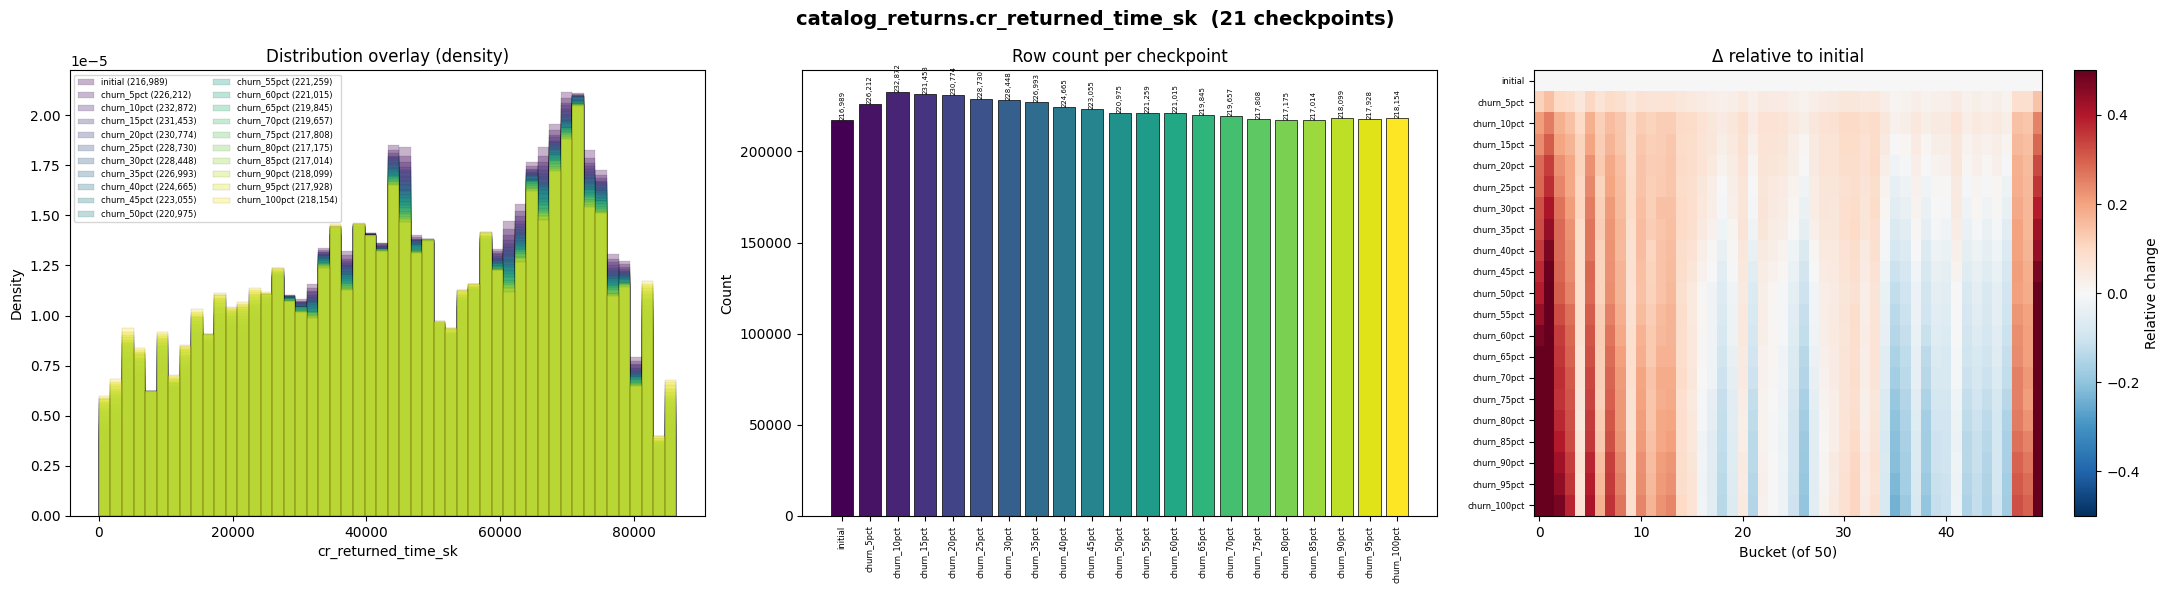

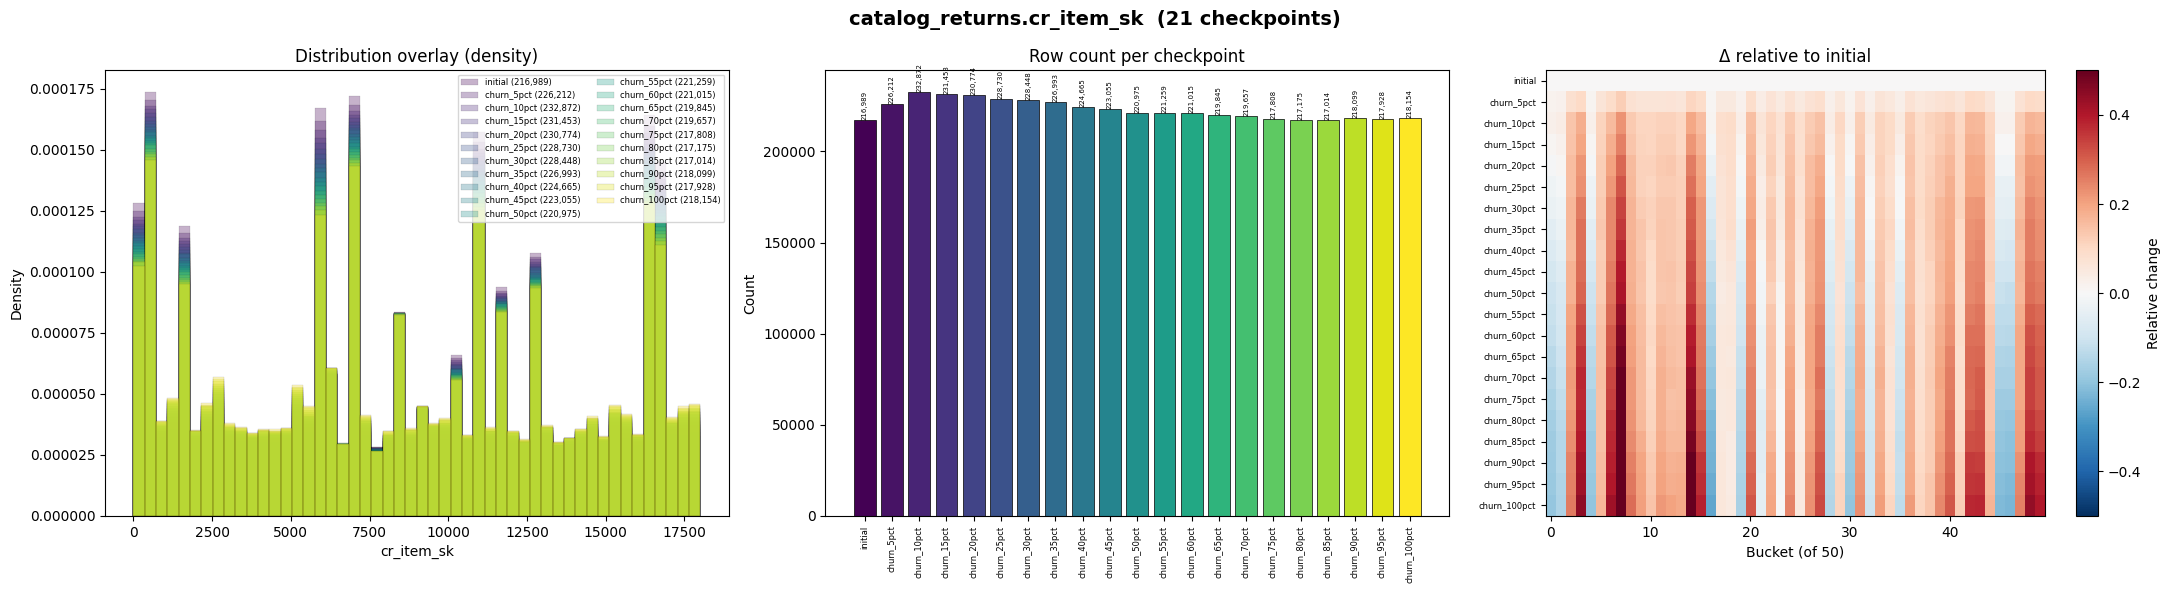

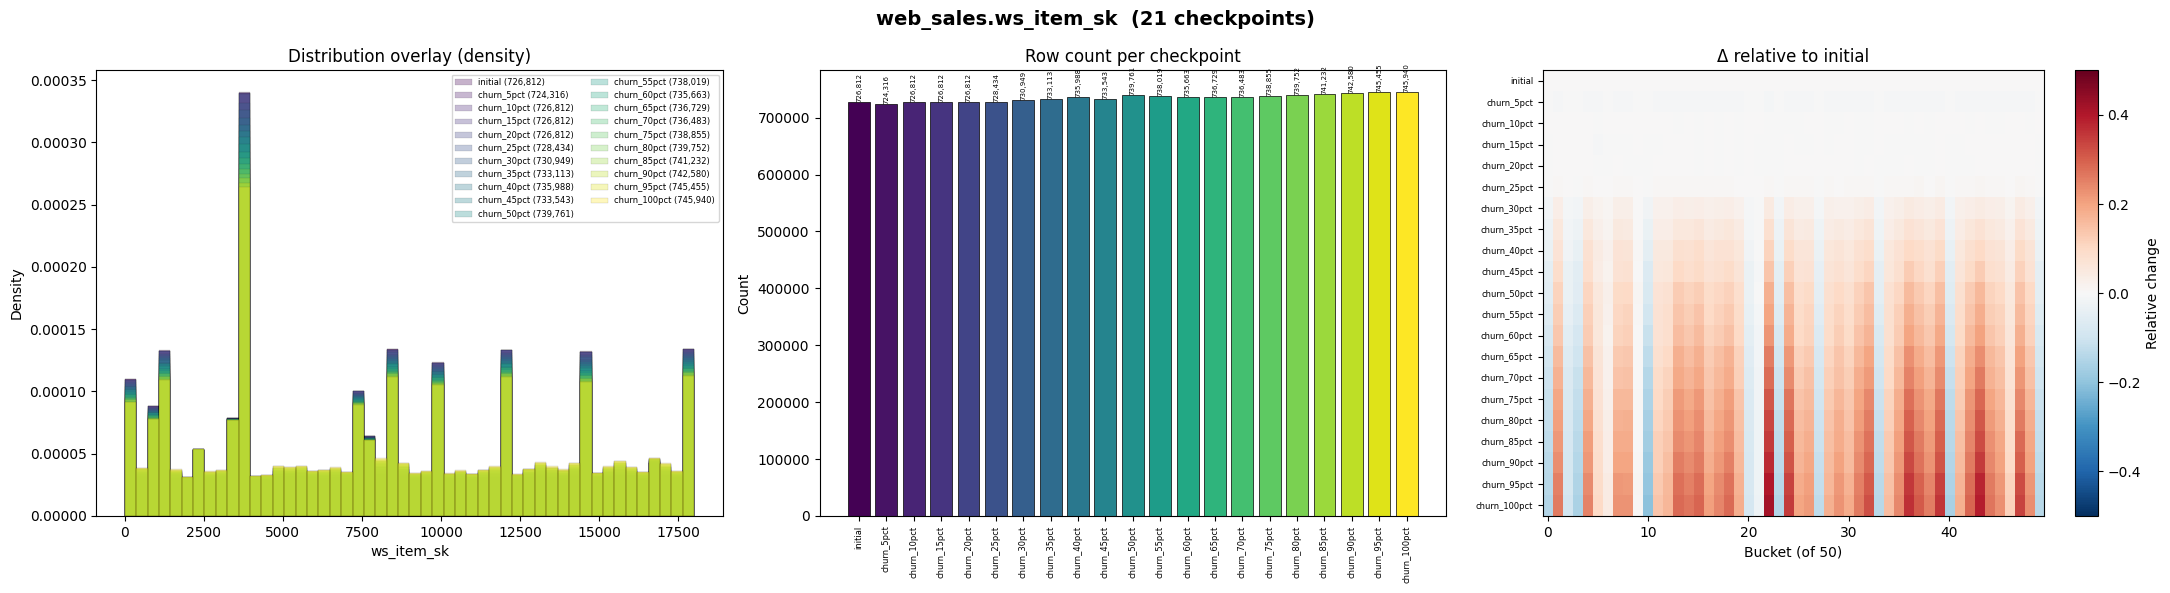

In [ ]:
def plot_checkpoint_evolution(ckpt_manager, bins=50):

    for key in ckpt_manager.keys:

        labels = list(ckpt_manager.checkpoints[key].keys())
        n = len(labels)
        colors = plt.cm.viridis(np.linspace(0, 1, n))

        fig, axes = plt.subplots(1, 3, figsize=(22, 6))
        fig.suptitle(f"{key}  ({n} checkpoints)", fontsize=14, fontweight='bold')

        # --- 1. Overlay histograms ---
        ax = axes[0]
        for i, label in enumerate(labels):
            data = ckpt_manager.checkpoints[key][label].astype(float).dropna()
            ax.hist(data, bins=bins, alpha=0.3, density=True,
                    label=f'{label} ({len(data):,})',
                    color=colors[i], edgecolor='black', linewidth=0.2)
        ax.set_title('Distribution overlay (density)')
        ax.legend(fontsize=6, ncol=2)
        ax.set_ylabel('Density')
        ax.set_xlabel(key.split('.')[-1])

        # --- 2. Row count evolution ---
        ax = axes[1]
        counts = [len(ckpt_manager.checkpoints[key][l]) for l in labels]
        bars = ax.bar(range(n), counts, color=colors, edgecolor='black', linewidth=0.5)
        ax.set_xticks(range(n))
        ax.set_xticklabels(labels, rotation=90, ha='center', fontsize=6)
        ax.set_title('Row count per checkpoint')
        ax.set_ylabel('Count')
        for j, c in enumerate(counts):
            ax.text(j, c, f'{c:,}', ha='center', va='bottom', fontsize=5, rotation=90)

        # --- 3. Delta heatmap ---
        ax = axes[2]
        initial = ckpt_manager.checkpoints[key][labels[0]].astype(float).dropna()
        _, base_edges = np.histogram(initial, bins=bins)

        heat = []
        for label in labels:
            data = ckpt_manager.checkpoints[key][label].astype(float).dropna()
            h, _ = np.histogram(data, bins=base_edges)
            heat.append(h)
        heat = np.array(heat)

        if heat[0].sum() > 0:
            delta_heat = (heat - heat[0]) / (heat[0] + 1)
        else:
            delta_heat = heat

        im = ax.imshow(delta_heat, aspect='auto', cmap='RdBu_r',
                       vmin=-0.5, vmax=0.5)
        ax.set_yticks(range(n))
        ax.set_yticklabels(labels, fontsize=6)
        ax.set_xlabel(f'Bucket (of {bins})')
        ax.set_title('Δ relative to initial')
        plt.colorbar(im, ax=ax, label='Relative change')

        plt.tight_layout()
        plt.show()


plot_checkpoint_evolution(ckpt, bins=50)

In [ ]:
# ============================================================
# Доступ к сохранённым чекпойнтам
# ============================================================

# Все чекпойнты доступны через:
print("Available checkpoints:", list(ckpt.checkpoints.keys()))

# Пример: получить данные конкретного чекпойнта
initial_cr_item = ckpt.checkpoints['initial']['catalog_returns.cr_item_sk']
print(f"\nInitial cr_item_sk: {len(initial_cr_item):,} values")

# Или создать именованные переменные:
for label, data in ckpt.checkpoints.items():
    var_name = f"targeted_{label.replace(' ', '_')}"
    globals()[var_name] = data
    print(f"  Created: {var_name}")

# Теперь доступны как:
#   targeted_initial['catalog_returns.cr_item_sk']
#   targeted_after_stream_1['web_sales.ws_item_sk']
#   ...

In [ ]:
# ============================================================
# Export checkpoints to CSV
# ============================================================

EXPORT_DIR = "/content/drive/MyDrive/data1gbDBS/checkpoints"
os.makedirs(EXPORT_DIR, exist_ok=True)

for key in ckpt.keys:
    # key = "catalog_returns.cr_item_sk"
    safe_name = key.replace('.', '__')  # для имени файла

    for label, series in ckpt.checkpoints[key].items():
        filename = f"{safe_name}__{label}.csv"
        filepath = os.path.join(EXPORT_DIR, filename)
        series.to_csv(filepath, index=False, header=[key.split('.')[-1]])

print(f"Exported to: {EXPORT_DIR}")
print(f"Total files: {sum(len(v) for v in ckpt.checkpoints.values())}")

# Проверка
for key in ckpt.keys:
    safe_name = key.replace('.', '__')
    files = sorted(f for f in os.listdir(EXPORT_DIR) if f.startswith(safe_name))
    print(f"\n{key}: {len(files)} files")
    for f in files:
        size = os.path.getsize(os.path.join(EXPORT_DIR, f))
        print(f"  {f}  ({size:,} bytes)")

Exported to: /content/drive/MyDrive/data1gbDBS/checkpoints
Total files: 63

catalog_returns.cr_returned_time_sk: 21 files
  catalog_returns__cr_returned_time_sk__churn_100pct.csv  (1,290,338 bytes)
  catalog_returns__cr_returned_time_sk__churn_10pct.csv  (1,382,387 bytes)
  catalog_returns__cr_returned_time_sk__churn_15pct.csv  (1,373,561 bytes)
  catalog_returns__cr_returned_time_sk__churn_20pct.csv  (1,369,100 bytes)
  catalog_returns__cr_returned_time_sk__churn_25pct.csv  (1,356,733 bytes)
  catalog_returns__cr_returned_time_sk__churn_30pct.csv  (1,354,755 bytes)
  catalog_returns__cr_returned_time_sk__churn_35pct.csv  (1,345,896 bytes)
  catalog_returns__cr_returned_time_sk__churn_40pct.csv  (1,331,809 bytes)
  catalog_returns__cr_returned_time_sk__churn_45pct.csv  (1,321,974 bytes)
  catalog_returns__cr_returned_time_sk__churn_50pct.csv  (1,309,367 bytes)
  catalog_returns__cr_returned_time_sk__churn_55pct.csv  (1,310,747 bytes)
  catalog_returns__cr_returned_time_sk__churn_5pct.c